In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np

# 드라이브 마운트
drive.mount('/content/drive')

# 1. 파일이 저장된 정확한 경로 (본인의 경로에 맞게 수정하세요)
base_path = '/content/drive/MyDrive/ColabNotebooks/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# DATA_1_cohort_대상자추출.csv

In [ ]:
# 데이터 불러오기 (파일 경로를 본인의 환경에 맞게 수정하세요)
admissions = pd.read_csv(f'{base_path}hosp/admissions.csv.gz', compression='gzip')
patients = pd.read_csv(f'{base_path}hosp/patients.csv.gz', compression='gzip')
diagnoses_icd = pd.read_csv(f'{base_path}hosp/diagnoses_icd.csv.gz', compression='gzip')
icustays = pd.read_csv(f'{base_path}icu/icustays.csv.gz', compression='gzip')

# 날짜 데이터를 문자열에서 파이썬 날짜 객체(datetime)로 변환 (계산을 위해 필수!)
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['edregtime'] = pd.to_datetime(admissions['edregtime'])
admissions['edouttime'] = pd.to_datetime(admissions['edouttime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])
patients['anchor_age'] = pd.to_numeric(patients['anchor_age'])

In [ ]:
##### 수빈님이랑 N수 동일한 것 확인 완료 #####
##### gender만 추가해서 다시 진행 #####

# 1. 데이터 병합 (초기 단계)
# admissions와 patients를 병합합니다.
df_base = pd.merge(admissions, patients[['subject_id', 'anchor_age', 'anchor_year', 'gender']], on='subject_id', how='left')

# ---------------------------------------------------------
# 단계 1: 입원 시점 정확한 나이(age_at_admission) 계산
# ---------------------------------------------------------
# 공식: anchor_age + (admittime의 연도 - anchor_year)
df_base['age_at_admission'] = df_base['anchor_age'] + (df_base['admittime'].dt.year - df_base['anchor_year'])

# 만 18세 이상만 필터링 (결과를 df_step1에 저장)
df_step1 = df_base[df_base['age_at_admission'] >= 18].copy()
print(f"1단계 (입원 시점 18세 이상) 환자 수: {df_step1['hadm_id'].nunique()}")

# ---------------------------------------------------------
# 단계 2: 응급실 경유 환자만 필터링
# ---------------------------------------------------------
df_step2 = df_step1[df_step1['admission_location'].str.contains('EMERGENCY ROOM', na=False)].copy()
print(f"2단계 (ER 경유 추가) 환자 수: {df_step2['hadm_id'].nunique()}")

# ---------------------------------------------------------
# 단계 3: 응급실 체류 시간 계산 및 1시간 미만 제외
# ---------------------------------------------------------
df_final = df_step2.copy()
# 단위: 시간(Hours)
df_final['ed_stay_duration'] = (df_final['edouttime'] - df_final['edregtime']).dt.total_seconds() / 3600
df_final = df_final[df_final['ed_stay_duration'] >= 1].copy()

print(f"3단계 (1시간 이상 체류 추가) 환자 수: {df_final['hadm_id'].nunique()}")

# ---------------------------------------------------------
# 4. 결과 저장
# ---------------------------------------------------------
df_final.to_csv('cohort_step1.csv', index=False, encoding='utf-8-sig')

1단계 (입원 시점 18세 이상) 환자 수: 546028
2단계 (ER 경유 추가) 환자 수: 244179
3단계 (1시간 이상 체류 추가) 환자 수: 241396


# DATA_2_cohort_TimeWindow.csv

In [ ]:
##### cohort_step2_ver.2#####

cohort = pd.read_csv(f'/content/cohort_step1.csv')

# 'edregtime' 컬럼을 datetime 형식으로 변환
cohort['edregtime'] = pd.to_datetime(cohort['edregtime'])

# 1. 검사 한정 시간대 (Window 1): edregtime ~ edregtime + 6시간
cohort['window1_start'] = cohort['edregtime']
cohort['window1_end'] = cohort['edregtime'] + pd.Timedelta(hours=6)

# 2. Outcome 한정 시간대 (Window 2): edregtime + 48시간
cohort['window2_start'] = cohort['edregtime'] + pd.Timedelta(hours=6)
cohort['window2_end'] = cohort['edregtime'] + pd.Timedelta(hours=48)

cohort.to_csv('cohort_step2_ver.2.csv', index=False, encoding='utf-8-sig')

# DATA_3_cohort_LabChartOutput.csv
## - 조인은 SQLDEVELOPER로 진행 (용량 이슈)
## - SQLDEVELOER 코드는 DOCS로 별도 첨부

In [ ]:
##### cohort_lab_chart_output.csv 전체 n수, 환자 수, 결측치 확인 #####

import pandas as pd

# 1. CSV 파일 불러오기
# 파일이 코랩 왼쪽 폴더 아이콘(세션 저장소)에 업로드되어 있어야 합니다.
cohort_lco = pd.read_csv(f'{base_path}cohort_csv/cohort_lab_chart_output.csv')

# 2. 전체 데이터 구조 확인 (행, 열 수)
print(f"총 데이터 행 수: {cohort_lco.shape[0]}개")
print(f"총 컬럼 수: {cohort_lco.shape[1]}개")
print("-" * 30)

# 3. 환자 수 확인 (ID 기준 중복 제거)
# subject_id: 환자 고유 번호 / hadm_id: 입원 고유 번호
# 'subject_id'와 'hadm_id' 컬럼 이름이 대문자로 되어 있어 수정합니다.
num_subjects = cohort_lco['SUBJECT_ID'].nunique()
num_admissions = cohort_lco['HADM_ID'].nunique()

print(f"고유 환자 수(SUBJECT_ID 기준): {num_subjects}명")
print(f"고유 입원 건수(HADM_ID 기준): {num_admissions}건")
print("-" * 30)

# 4. 데이터 비율 확인 (%)
print("\n컬럼별 데이터 비율(%):")
print((1-cohort_lco.isnull().sum() / len(cohort_lco)) * 100)

# 5. 모든 컬럼이 채워진(결측치가 없는) 행의 수 확인
# how='any'는 하나라도 결측치가 있으면 제외한다는 뜻입니다.
complete_rows = cohort_lco.dropna(how='any')
num_complete_rows = len(complete_rows)
complete_ratio = (num_complete_rows / len(cohort_lco)) * 100
print("-" * 30)

print(f"모든 컬럼이 채워진 행 수: {num_complete_rows}개")
print(f"전체 대비 완전한 데이터 비율: {complete_ratio:.2f}%")
print("-" * 30)

# 6. 완전한 데이터 내에서의 고유 환자 수
num_complete_subjects = complete_rows['SUBJECT_ID'].nunique()
print(f"완전한 데이터 내 고유 환자 수: {num_complete_subjects}명")

총 데이터 행 수: 241396개
총 컬럼 수: 42개
------------------------------
고유 환자 수(SUBJECT_ID 기준): 122487명
고유 입원 건수(HADM_ID 기준): 241396건
------------------------------

컬럼별 데이터 비율(%):
SUBJECT_ID              100.000000
HADM_ID                 100.000000
ADMITTIME               100.000000
AGE_AT_ADMISSION        100.000000
HOSPITAL_EXPIRE_FLAG    100.000000
HEART_RATE                7.179904
SBP                       7.104923
DBP                       7.103680
MAP                       7.099952
RESP_RATE                 7.213873
TEMP                      6.797959
SPO2                      7.116936
GLUCOSE_CHART             3.484316
FIO2                      2.608163
GCS                       6.467381
WBC                      17.121659
HB                       17.137815
PLATELET                 17.133258
LACTATE                   7.867570
CREATININE               17.446022
BUN                      17.426966
GLUCOSE_LAB              17.088104
INR                       9.293857
PT                      

# DATA_4_data_결측치70%이상제외.csv

In [ ]:
##### 엑셀이랑 다른 점 해결 중 ##### -> 해결 완료 ! (260108) 기헌님이 sqldeveloper로 적재 예정

# 1. 검사 항목이 시작되는 'HR' 컬럼부터 마지막 컬럼까지 선택
# .loc을 사용하여 열 범위를 지정합니다.
inspection_cols = cohort_lco.loc[:, 'HEART_RATE':]

# 2. 선택된 검사 항목들에 대해서만 행별 결측치 비율 계산 (0~1 사이)
# axis=1은 가로 방향(행별) 계산을 의미합니다.
inspection_missing_ratio = inspection_cols.isnull().mean(axis=1)

# 3. 결측치가 70% 미만인 경우 (= 데이터가 30% 이상 채워진 경우) 필터링
# mask_valid는 우리가 분석에 사용할 '정보량이 충분한' 행들을 골라냅니다.
mask_valid = inspection_missing_ratio < 0.7
df_filtered = cohort_lco[mask_valid].copy()

# 4. 결과 집계 (N수 확인)
final_subjects_n = df_filtered['SUBJECT_ID'].nunique()
final_hadms_n = df_filtered['HADM_ID'].nunique()
total_rows_n = len(df_filtered)

print(f"--- 검사 항목(HR 이후) 데이터 30% 이상 충족 기준 ---")
print(f"1. 필터링 후 전체 행(Record) 수: {total_rows_n}개")
print(f"2. 고유 환자 수 (SUBJECT_ID): {final_subjects_n}명")
print(f"3. 고유 입원 건수 (HADM_ID): {final_hadms_n}건")
print("-" * 30)

# .loc을 사용하여 열 범위를 지정합니다.
inspection_cols = cohort_lco.loc[:, 'HEART_RATE':]

# 2. 선택된 검사 항목들에 대해서만 행별 결측치 비율 계산 (0~1 사이)
# axis=1은 가로 방향(행별) 계산을 의미합니다.
inspection_missing_ratio = inspection_cols.isnull().mean(axis=1)

# 3. 결측치가 50% 미만인 경우 (= 데이터가 50% 이상 채워진 경우) 필터링
# mask_valid는 우리가 분석에 사용할 '정보량이 충분한' 행들을 골라냅니다.
mask_valid = inspection_missing_ratio < 0.5
df_filtered = cohort_lco[mask_valid].copy()

# 4. 결과 집계 (N수 확인)
final_subjects_n = df_filtered['SUBJECT_ID'].nunique()
final_hadms_n = df_filtered['HADM_ID'].nunique()
total_rows_n = len(df_filtered)

print(f"--- 검사 항목(HR 이후) 데이터 50% 이상 충족 기준 ---")
print(f"1. 필터링 후 전체 행(Record) 수: {total_rows_n}개")
print(f"2. 고유 환자 수 (SUBJECT_ID): {final_subjects_n}명")
print(f"3. 고유 입원 건수 (HADM_ID): {final_hadms_n}건")


--- 검사 항목(HR 이후) 데이터 30% 이상 충족 기준 ---
1. 필터링 후 전체 행(Record) 수: 43171개
2. 고유 환자 수 (SUBJECT_ID): 34203명
3. 고유 입원 건수 (HADM_ID): 43171건
------------------------------
--- 검사 항목(HR 이후) 데이터 50% 이상 충족 기준 ---
1. 필터링 후 전체 행(Record) 수: 9915개
2. 고유 환자 수 (SUBJECT_ID): 9126명
3. 고유 입원 건수 (HADM_ID): 9915건


In [ ]:
cohort_lco = pd.read_csv(f'{base_path}cohort_csv/cohort_lab_chart_output.csv')
cohort_lco.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,AGE_AT_ADMISSION,HOSPITAL_EXPIRE_FLAG,HEART_RATE,SBP,DBP,MAP,RESP_RATE,...,ALBUMIN,GLOBULIN,TOTAL_PROTEIN,CALCIUM,URINE_PROTEIN,URINE_SPEC_GRAVITY,TOTAL_URINE_OUTPUT,SHOCK_INDEX,ANION_GAP_APPROX,BUN_CR_RATIO
0,10000032,22841357,2180-06-26,52,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10000032,29079034,2180-07-23,52,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10000032,25742920,2180-08-05,52,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10000068,25022803,2160-03-03,19,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10000108,27250926,2163-09-27,25,0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
##### 수빈님 요청(inputevents.gz) - vaso 승압제 1종 -> 5종 #####

import pandas as pd
import numpy as np

# 1. 데이터 불러오기
inputevents = pd.read_csv(f'{base_path}icu/inputevents.csv.gz', compression='gzip')

def extract_vasopressin(df):
    # 여러 itemid를 올바르게 필터링합니다.
    vaso_df = df[df['itemid'].isin([222315, 221653, 221662, 221289, 221906])].copy()

    # 약물 이름 매핑
    drug_map = {
        222315: 'Vasopressin',
        221653: 'Dobutamine',
        221662: 'Dopamine',
        221289: 'Epinephrine',
        221906: 'Norepinephrine'
    }
    vaso_df['drug_name'] = vaso_df['itemid'].map(drug_map)

    # [단위 표준화 함수 정의]
    def normalize_rate(row):
        itemid = row['itemid']
        rate = row['rate']
        rateuom = row['rateuom']
        weight = row.get('patientweight', 1) # 무게 정보가 없으면 1로 간주

        # 1. Vasopressin 처리 (units/hour로 통일)
        if itemid == 222315:
            if rateuom == 'units/min':
                return rate * 60.0
            return rate

        # 2. 나머지 승압제 처리 (mcg/kg/min으로 통일)
        else:
            if rateuom == 'mg/kg/min':
                # 무게 정보가 없으면 1로 간주했으므로, weight=1일 때도 1000.0을 곱해야 함
                return rate * 1000.0 # mg -> mcg 변환
            return rate # 이미 mcg이거나 ug인 경우

    # 단위 변환 적용
    vaso_df['normalized_rate'] = vaso_df.apply(normalize_rate, axis=1)

    # 표준화된 단위 명시
    vaso_df['normalized_rateuom'] = np.where(
        vaso_df['itemid'] == 222315, 'units/hour', 'mcg/kg/min'
    )

    # 필요한 컬럼만 선택
    result = vaso_df[[
        'stay_id', 'linkorderid', 'itemid', 'drug_name',
        'normalized_rate', 'normalized_rateuom',
        'amount', 'starttime', 'endtime'
    ]].copy()

    return result

# 실행 예시
v_processed = extract_vasopressin(inputevents) # vaso_df를 extract_vasopressin으로 수정
print(v_processed.head())

v_processed.to_csv('vaso.csv', index=False, encoding='utf-8-sig')

      stay_id  linkorderid  itemid drug_name  normalized_rate  \
157  37510196       965663  221662  Dopamine         7.004377   
264  37510196       965663  221662  Dopamine         8.008121   
276  37510196       965663  221662  Dopamine         6.003609   
278  37510196       965663  221662  Dopamine         2.001203   
386  37510196       965663  221662  Dopamine        10.006255   

    normalized_rateuom     amount            starttime              endtime  
157         mcg/kg/min  20.943088  2131-01-11 06:54:00  2131-01-11 07:40:00  
264         mcg/kg/min  19.259529  2131-01-11 07:40:00  2131-01-11 08:17:00  
276         mcg/kg/min  22.243372  2131-01-11 08:17:00  2131-01-11 09:14:00  
278         mcg/kg/min   6.113676  2131-01-11 09:14:00  2131-01-11 10:01:00  
386         mcg/kg/min   9.105691  2131-01-11 04:50:00  2131-01-11 05:04:00  


In [ ]:
print(len(v_processed))

556807


In [ ]:
import pandas as pd

# 1. SQL에서 추출하여 저장한 CSV 파일을 불러온다고 가정
# 만약 DB 직접 연결이 필요하면 sqlalchemy 라이브러리를 사용합니다.
#df_sepsis = pd.read_csv('sepsis_patients.csv')

# 2. 기본적인 데이터 확인
#print(f"전체 패혈증 환자 수(입원 건수 기준): {df_sepsis['hadm_id'].nunique()}")

# **결측치 확인**

In [ ]:
pip install oracledb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.1 MB/s eta 0:00:00


In [ ]:
pip install squarify

In [ ]:
# 기초 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import oracledb
import squarify
from scipy import stats

In [ ]:
df = pd.read_csv(f'{base_path}cohort_csv/data.csv')
df.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,AGE_AT_ADMISSION,HOSPITAL_EXPIRE_FLAG,GENDER,HEART_RATE,SBP,DBP,MAP,...,ALBUMIN,CALCIUM,URINE_PROTEIN,URINE_SPEC_GRAVITY,TOTAL_URINE_OUTPUT,SHOCK_INDEX,ANION_GAP_APPROX,BUN_CR_RATIO,SOFA_TOTAL,SEPSIS
0,12362515,22801443,2155-04-23,56,0,M,NaN,NaN,NaN,NaN,...,3.6,NaN,NaN,1.005,NaN,NaN,NaN,12.73,0,0
1,15476958,20374445,2150-07-04,41,0,M,NaN,NaN,NaN,NaN,...,NaN,10.3,NaN,NaN,NaN,NaN,16.0,16.00,3,0
2,10543727,22797581,2171-08-06,49,0,F,92.666667,125.25,70.25,81.75,...,NaN,NaN,NaN,NaN,175.0,0.74,NaN,NaN,8,0
3,10010867,22429197,2147-12-30,28,0,F,96.166667,119.25,59.50,72.75,...,NaN,NaN,NaN,NaN,680.0,0.81,NaN,NaN,4,0
4,10193074,22392305,2121-02-11,31,0,F,103.666667,104.50,63.50,73.50,...,NaN,NaN,NaN,NaN,130.0,0.99,NaN,NaN,10,0


In [ ]:
df.columns

Index(['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'AGE_AT_ADMISSION',
       'HOSPITAL_EXPIRE_FLAG', 'GENDER', 'HEART_RATE', 'SBP', 'DBP', 'MAP',
       'RESP_RATE', 'TEMP', 'SPO2', 'GLUCOSE_CHART', 'FIO2', 'GCS', 'WBC',
       'HB', 'PLATELET', 'LACTATE', 'CREATININE', 'BUN', 'GLUCOSE_LAB', 'INR',
       'PT', 'PTT', 'SODIUM', 'POTASSIUM', 'CHLORIDE', 'BICARBONATE',
       'BILIRUBIN', 'PAO2', 'CRP', 'ALBUMIN', 'CALCIUM', 'URINE_PROTEIN',
       'URINE_SPEC_GRAVITY', 'TOTAL_URINE_OUTPUT', 'SHOCK_INDEX',
       'ANION_GAP_APPROX', 'BUN_CR_RATIO', 'SOFA_TOTAL', 'SEPSIS'],
      dtype='object')

In [ ]:
##### 행 결측치 계산 #####

# .loc을 사용하여 열 범위를 지정합니다.
inspection_cols = df.loc[:, 'HEART_RATE':]

# 2. 선택된 검사 항목들에 대해서만 행별 결측치 비율 계산 (0~1 사이)
# axis=1은 가로 방향(행별) 계산을 의미합니다.
inspection_missing_ratio = inspection_cols.isnull().mean(axis=1)

# 3. 결측치가 70% 미만인 경우 (= 데이터가 30% 이상 채워진 경우) 필터링
# mask_valid는 우리가 분석에 사용할 '정보량이 충분한' 행들을 골라냅니다.
mask_valid = inspection_missing_ratio < 0.7
df_filtered = df[mask_valid].copy()

# 4. 결과 집계 (N수 확인)
final_subjects_n = df_filtered['SUBJECT_ID'].nunique()
final_hadms_n = df_filtered['HADM_ID'].nunique()
total_rows_n = len(df_filtered)

print(f"--- 검사 항목(HR 이후) 데이터 30% 이상 충족 기준 ---")
print(f"1. 필터링 후 전체 행(Record) 수: {total_rows_n}개")
print(f"2. 고유 환자 수 (SUBJECT_ID): {final_subjects_n}명")
print(f"3. 고유 입원 건수 (HADM_ID): {final_hadms_n}건")


--- 검사 항목(HR 이후) 데이터 30% 이상 충족 기준 ---
1. 필터링 후 전체 행(Record) 수: 43171개
2. 고유 환자 수 (SUBJECT_ID): 34203명
3. 고유 입원 건수 (HADM_ID): 43171건


# **columns 정리**

In [ ]:
id_cols = ["SUBJECT_ID", "HADM_ID", "ADMITTIME"]
outcome_col = "HOSPITAL_EXPIRE_FLAG"
cat_cols = [
    "GENDER",
]
cont_cols = [
    "AGE_AT_ADMISSION",
    "HEART_RATE","SBP","DBP","MAP","RESP_RATE","TEMP","SPO2",
    "GLUCOSE_CHART","FIO2","GCS",
    "WBC","HB","PLATELET","LACTATE","CREATININE","BUN","GLUCOSE_LAB",
    "INR","PT","PTT","SODIUM","POTASSIUM","CHLORIDE","BICARBONATE",
    "BILIRUBIN","PAO2","CRP","ALBUMIN",
    "CALCIUM","TOTAL_URINE_OUTPUT","SHOCK_INDEX",
    "ANION_GAP_APPROX","BUN_CR_RATIO",
    "SOFA_TOTAL"
]

# **columns type 정리**

### type 변환

In [ ]:
df[cont_cols] = df[cont_cols].apply(
    pd.to_numeric, errors="coerce"
)

In [ ]:
for c in cat_cols:
    df[c] = df[c].astype("category")

In [ ]:
# df[cont_cols].dtypes
df[cat_cols].dtypes

,0
GENDER,category


In [ ]:
print("전체 행/열:", df.shape)
df[[outcome_col]].value_counts()

전체 행/열: (43171, 43)


,count
HOSPITAL_EXPIRE_FLAG,
0,41413
1,1758


In [ ]:
# 연속형
summary_all = pd.DataFrame({
    "Mean":df[cont_cols].mean(),
    "Max":df[cont_cols].max(),
    "Min":df[cont_cols].min(),
    "Median": df[cont_cols].median(),
    "Q1": df[cont_cols].quantile(0.25),
    "Q3": df[cont_cols].quantile(0.75)
})
summary_all

# 저장 시
# summary_all.to_csv('summary_all.csv',index=False)

,Mean,Max,Min,Median,Q1,Q3
AGE_AT_ADMISSION,58.793542,100.000000,18.000000,60.000000,45.0000,74.000000
HEART_RATE,88.073731,168.166667,27.166667,86.666667,74.0000,100.906250
SBP,122.778927,232.000000,51.600000,120.414286,107.2500,135.666667
DBP,67.990436,157.000000,17.000000,67.000000,58.0000,76.500000
MAP,81.572549,179.833333,25.000000,80.000000,71.0000,90.666667
RESP_RATE,19.663705,43.666667,7.000000,19.000000,16.5000,22.000000
TEMP,36.675753,41.000000,28.000000,37.000000,36.0000,37.000000
SPO2,97.310756,100.000000,26.600000,98.000000,96.0000,99.600000
GLUCOSE_CHART,168.590980,948.000000,20.000000,139.000000,110.0000,193.000000
FIO2,62.989731,100.000000,21.000000,50.000000,45.0000,80.000000


In [ ]:
null_rate = (
    df[cont_cols]
    .isnull()
    .mean()
    .sort_values(ascending=False)
)

null_rate

,0
CRP,0.958074
FIO2,0.901948
PAO2,0.887494
TOTAL_URINE_OUTPUT,0.850224
GLUCOSE_CHART,0.842973
GCS,0.816173
TEMP,0.813046
SPO2,0.804753
SHOCK_INDEX,0.804661
SBP,0.804498


In [ ]:
# 범주형
for c in cat_cols:
    print("\n", c)
    print(data[c].value_counts(dropna=False))


 GENDER
GENDER
F    22210
M    20961
Name: count, dtype: int64


In [ ]:
analysis_cols = (
    [outcome_col]
    + cont_cols
    + cat_cols
)

In [ ]:
analysis_cols = [c for c in analysis_cols if c in df.columns]

len(analysis_cols), analysis_cols

(37,
 ['HOSPITAL_EXPIRE_FLAG',
  'AGE_AT_ADMISSION',
  'HEART_RATE',
  'SBP',
  'DBP',
  'MAP',
  'RESP_RATE',
  'TEMP',
  'SPO2',
  'GLUCOSE_CHART',
  'FIO2',
  'GCS',
  'WBC',
  'HB',
  'PLATELET',
  'LACTATE',
  'CREATININE',
  'BUN',
  'GLUCOSE_LAB',
  'INR',
  'PT',
  'PTT',
  'SODIUM',
  'POTASSIUM',
  'CHLORIDE',
  'BICARBONATE',
  'BILIRUBIN',
  'PAO2',
  'CRP',
  'ALBUMIN',
  'CALCIUM',
  'TOTAL_URINE_OUTPUT',
  'SHOCK_INDEX',
  'ANION_GAP_APPROX',
  'BUN_CR_RATIO',
  'SOFA_TOTAL',
  'GENDER'])

In [ ]:
row_missing_df = (
    df
    .assign(row_missing_ratio=df[analysis_cols].isnull().mean(axis=1))
    .loc[:, ["SUBJECT_ID", "row_missing_ratio"]]
)

In [ ]:
row_missing_ranked = row_missing_df.sort_values(
    by="row_missing_ratio",
    ascending=False
).reset_index(drop=True)

row_missing_ranked.head(20)

,SUBJECT_ID,row_missing_ratio
0,14500834,0.621622
1,14908173,0.621622
2,15112941,0.621622
3,14609218,0.621622
4,14617033,0.621622
5,16950153,0.621622
6,17081205,0.621622
7,17096041,0.621622
8,17175999,0.621622
9,16398746,0.621622


In [ ]:
pd.cut(
    row_missing_ranked["row_missing_ratio"],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=["≤30%", "30-50%", "50-70%", ">70%"]
).value_counts().sort_index()

,count
row_missing_ratio,
≤30%,5877
30-50%,20222
50-70%,17014
>70%,0


In [ ]:
# row_missing_ratio가 0인 행의 개수 확인
num_zero_missing = (row_missing_ranked['row_missing_ratio'] == 0).sum()
print(f"row_missing_ratio가 0인 행의 개수: {num_zero_missing}개")

row_missing_ratio가 0인 행의 개수: 58개


In [ ]:
# include_lowest=True 옵션을 추가하여 다시 계산
pd.cut(
    row_missing_ranked["row_missing_ratio"],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=["≤30%", "30-50%", "50-70%", ">70%"],
    include_lowest=True
).value_counts().sort_index()

,count
row_missing_ratio,
≤30%,5935
30-50%,20222
50-70%,17014
>70%,0


In [ ]:
# 예: 관측률 30% 미만(= 결측률 > 70%) 제거 대상 표시
# row_missing_ranked["exclude_flag"] = row_missing_ranked["row_missing_ratio"] > 0.7

## 최근 값으로 GCS 점수 구하고, 기존 data의 gcs를 새로 바꾼 gcs로 변경


In [ ]:
import pandas as pd

data_gl = pd.read_csv(f'{base_path}cohort_csv/data_gcs_last.csv')
data = pd.read_csv(f'{base_path}cohort_csv/data.csv')

# 1. 기존 데이터에서 옛날 GCS 컬럼 삭제
if 'GCS' in data.columns:
    data = data.drop(columns=['GCS'])

# 2. 새로운 GCS 데이터 준비
add = data_gl[['SUBJECT_ID', 'HADM_ID', 'GCS']]

# 3. 병합 (이제 GCS는 새로운 값만 남게 됩니다)
df = pd.merge(data, add, on=['SUBJECT_ID', 'HADM_ID'], how='left')

print(f"현재 컬럼 목록: {df.columns.tolist()}")

# 4. 결과 확인
print(f"결합 전 행 수: {len(data)}")
print(f"결합 후 행 수: {len(df)}")

# 5. 전처리 완료된 데이터 CSV로 반출
df.to_csv('data_gcslast.csv', index=False, encoding='utf-8-sig')

df.head()


현재 컬럼 목록: ['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'AGE_AT_ADMISSION', 'HOSPITAL_EXPIRE_FLAG', 'GENDER', 'HEART_RATE', 'SBP', 'DBP', 'MAP', 'RESP_RATE', 'TEMP', 'SPO2', 'GLUCOSE_CHART', 'FIO2', 'WBC', 'HB', 'PLATELET', 'LACTATE', 'CREATININE', 'BUN', 'GLUCOSE_LAB', 'INR', 'PT', 'PTT', 'SODIUM', 'POTASSIUM', 'CHLORIDE', 'BICARBONATE', 'BILIRUBIN', 'PAO2', 'CRP', 'ALBUMIN', 'CALCIUM', 'URINE_PROTEIN', 'URINE_SPEC_GRAVITY', 'TOTAL_URINE_OUTPUT', 'SHOCK_INDEX', 'ANION_GAP_APPROX', 'BUN_CR_RATIO', 'SOFA_TOTAL', 'SEPSIS', 'GCS']
결합 전 행 수: 43171
결합 후 행 수: 43171


,SUBJECT_ID,HADM_ID,ADMITTIME,AGE_AT_ADMISSION,HOSPITAL_EXPIRE_FLAG,GENDER,HEART_RATE,SBP,DBP,MAP,...,CALCIUM,URINE_PROTEIN,URINE_SPEC_GRAVITY,TOTAL_URINE_OUTPUT,SHOCK_INDEX,ANION_GAP_APPROX,BUN_CR_RATIO,SOFA_TOTAL,SEPSIS,GCS
0,12362515,22801443,2155-04-23,56,0,M,NaN,NaN,NaN,NaN,...,NaN,NaN,1.005,NaN,NaN,NaN,12.73,0,0,NaN
1,15476958,20374445,2150-07-04,41,0,M,NaN,NaN,NaN,NaN,...,10.3,NaN,NaN,NaN,NaN,16.0,16.00,3,0,0.0
2,10543727,22797581,2171-08-06,49,0,F,92.666667,125.25,70.25,81.75,...,NaN,NaN,NaN,175.0,0.74,NaN,NaN,8,0,11.0
3,10010867,22429197,2147-12-30,28,0,F,96.166667,119.25,59.50,72.75,...,NaN,NaN,NaN,680.0,0.81,NaN,NaN,4,0,8.0
4,10193074,22392305,2121-02-11,31,0,F,103.666667,104.50,63.50,73.50,...,NaN,NaN,NaN,130.0,0.99,NaN,NaN,10,0,10.0


## **수빈님 EDA로 GCS 바꾼 후의 data 확인**

In [ ]:

# 컬럼 분류
id_cols = ['SUBJECT_ID', 'HADM_ID', 'ADMITTIME']
demographic_cols = ['AGE_AT_ADMISSION', 'GENDER']
outcome_cols = ['HOSPITAL_EXPIRE_FLAG', 'SEPSIS']
vital_cols = ['HEART_RATE', 'SBP', 'DBP', 'MAP', 'RESP_RATE', 'TEMP', 'SPO2', 'FIO2', 'GCS']
lab_cols = ['WBC', 'HB', 'PLATELET', 'LACTATE', 'CREATININE', 'BUN',
            'GLUCOSE_CHART', 'GLUCOSE_LAB', 'INR', 'PT', 'PTT',
            'SODIUM', 'POTASSIUM', 'CHLORIDE', 'BICARBONATE', 'BILIRUBIN',
            'PAO2', 'CRP','CALCIUM']
urine_cols = ['URINE_PROTEIN', 'URINE_SPEC_GRAVITY', 'TOTAL_URINE_OUTPUT']
calculated_cols = ['SHOCK_INDEX', 'ANION_GAP_APPROX', 'BUN_CR_RATIO', 'MISSING_RATIO']
sofa_cols = [col for col in df.columns if 'SOFA' in col]

print("\n변수 분류:")
print(f"- ID 컬럼: {len(id_cols)}개")
print(f"- 인구통계: {len(demographic_cols)}개")
print(f"- 결과 변수: {len(outcome_cols)}개")
print(f"- 활력징후: {len(vital_cols)}개")
print(f"- 혈액검사: {len(lab_cols)}개")
print(f"- 소변검사: {len(urine_cols)}개")
print(f"- 계산 지표: {len(calculated_cols)}개")
print(f"- SOFA 점수: {len(sofa_cols)}개")

# Target 변수 확인
print("\n" + "-" * 80)
print("Target 변수 분포 (SEPSIS):")
print(df['SEPSIS'].value_counts())
print(f"\n패혈증 발생률: {df['SEPSIS'].mean()*100:.2f}%")

if 'HOSPITAL_EXPIRE_FLAG' in df.columns:
    print("\n사망률:")
    print(df['HOSPITAL_EXPIRE_FLAG'].value_counts())
    print(f"전체 사망률: {df['HOSPITAL_EXPIRE_FLAG'].mean()*100:.2f}%")

    # 패혈증별 사망률
    mortality_by_sepsis = df.groupby('SEPSIS')['HOSPITAL_EXPIRE_FLAG'].agg(['sum', 'count', 'mean'])
    mortality_by_sepsis.columns = ['사망자수', '전체환자수', '사망률']
    mortality_by_sepsis['사망률'] = mortality_by_sepsis['사망률'] * 100
    print("\n패혈증 유무별 사망률:")
    print(mortality_by_sepsis)


변수 분류:
- ID 컬럼: 3개
- 인구통계: 2개
- 결과 변수: 2개
- 활력징후: 9개
- 혈액검사: 19개
- 소변검사: 3개
- 계산 지표: 4개
- SOFA 점수: 1개

--------------------------------------------------------------------------------
Target 변수 분포 (SEPSIS):
SEPSIS
0    40509
1     2662
Name: count, dtype: int64

패혈증 발생률: 6.17%

사망률:
HOSPITAL_EXPIRE_FLAG
0    41413
1     1758
Name: count, dtype: int64
전체 사망률: 4.07%

패혈증 유무별 사망률:
        사망자수  전체환자수        사망률
SEPSIS                        
0       1179  40509   2.910464
1        579   2662  21.750563



[5] 활력징후 분석

활력징후 기술통계:
             count        mean        std        min     25%         50%  \
HEART_RATE  8476.0   88.073731  19.293061  27.166667   74.00   86.666667   
SBP         8440.0  122.778927  21.419264  51.600000  107.25  120.414286   
DBP         8440.0   67.990436  14.569172  17.000000   58.00   67.000000   
MAP         8442.0   81.572549  15.240617  25.000000   71.00   80.000000   
RESP_RATE   8494.0   19.663705   4.449405   7.000000   16.50   19.000000   
TEMP        8071.0   36.675753   0.927779  28.000000   36.00   37.000000   
SPO2        8429.0   97.310756   3.463615  26.600000   96.00   98.000000   
FIO2        4233.0   62.989731  22.355573  21.000000   45.00   50.000000   
GCS         9235.0    9.488035   5.627328   0.000000    4.00   10.000000   

                   75%         max  결측률(%)  
HEART_RATE  100.906250  168.166667   80.37  
SBP         135.666667  232.000000   80.45  
DBP          76.500000  157.000000   80.45  
MAP          90.666667  179.833333

/tmp/ipython-input-1172580954.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
/tmp/ipython-input-1172580954.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
/tmp/ipython-input-1172580954.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
/tmp/ipython-input-1172580954.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = a

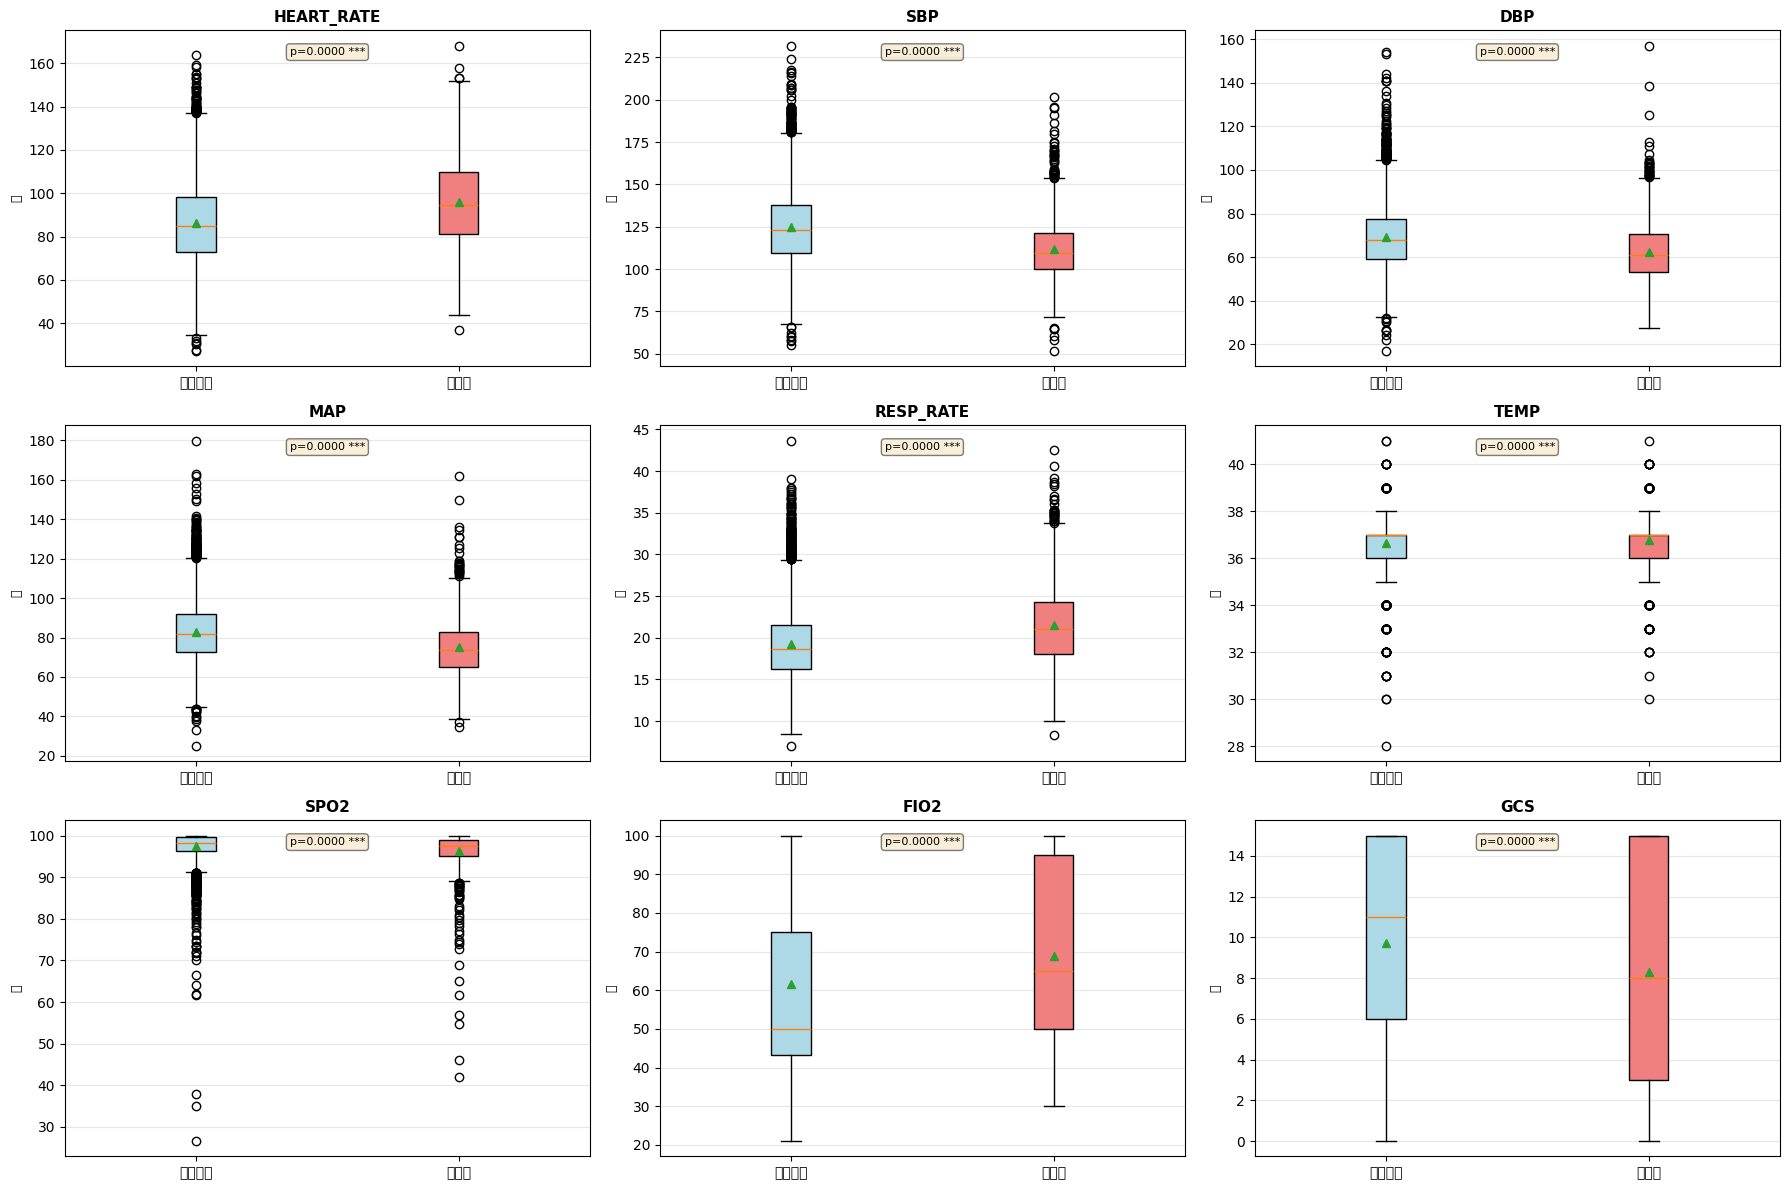

In [ ]:
# =============================================================================
# 5. 활력징후 분석
# =============================================================================
print("\n" + "=" * 80)
print("[5] 활력징후 분석")
print("=" * 80)

vital_analysis = df[vital_cols].describe().T
vital_analysis['결측률(%)'] = (df[vital_cols].isnull().sum() / len(df) * 100).round(2)
print("\n활력징후 기술통계:")
print(vital_analysis)

# 이상치 탐지 함수
def detect_outliers_iqr(data, multiplier=1.5):
    """IQR 방법으로 이상치 탐지"""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = (data < lower_bound) | (data > upper_bound)
    return outliers, lower_bound, upper_bound

# 활력징후별 이상치 분석
print("\n활력징후 이상치 분석 (IQR 방법, 1.5배):")
outlier_summary = []
for col in vital_cols:
    if col in df.columns and df[col].notna().sum() > 0:
        outliers, lower, upper = detect_outliers_iqr(df[col].dropna())
        outlier_count = outliers.sum()
        outlier_pct = (outlier_count / df[col].notna().sum() * 100)
        outlier_summary.append({
            '변수': col,
            '이상치 수': outlier_count,
            '이상치 비율(%)': round(outlier_pct, 2),
            '하한': round(lower, 2),
            '상한': round(upper, 2)
        })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

# 활력징후 분포 시각화
n_vitals = len([col for col in vital_cols if col in df.columns and df[col].notna().sum() > 0])
n_rows = (n_vitals + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows*4))
axes = axes.flatten() if n_vitals > 1 else [axes]

for idx, col in enumerate(vital_cols):
    if col in df.columns and df[col].notna().sum() > 0:
        ax = axes[idx]

        # 박스플롯과 바이올린 플롯 결합
        data_to_plot = [
            df[df['SEPSIS'] == 0][col].dropna(),
            df[df['SEPSIS'] == 1][col].dropna()
        ]

        bp = ax.boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
                        patch_artist=True, showmeans=True)

        # 색상 설정
        colors = ['lightblue', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)

        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_ylabel('값', fontsize=9)
        ax.grid(axis='y', alpha=0.3)

        # 통계 검정
        if len(data_to_plot[0]) > 0 and len(data_to_plot[1]) > 0:
            stat, p = stats.mannwhitneyu(data_to_plot[0], data_to_plot[1], alternative='two-sided')
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            ax.text(0.5, 0.95, f'p={p:.4f} {sig}',
                   transform=ax.transAxes, ha='center', va='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                   fontsize=8)

# 빈 subplot 제거
for idx in range(n_vitals, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('04_vital_signs.png', dpi=300, bbox_inches='tight')
plt.show()



[3] 결측치 분석

결측치가 있는 변수: 35개

결측률 상위 20개 변수:
                      결측수  결측률(%)
CRP                 41361   95.81
FIO2                38938   90.19
PAO2                38314   88.75
URINE_PROTEIN       38140   88.35
TOTAL_URINE_OUTPUT  36705   85.02
GLUCOSE_CHART       36392   84.30
GCS                 35235   81.62
TEMP                35100   81.30
SPO2                34742   80.48
SHOCK_INDEX         34738   80.47
SBP                 34731   80.45
MAP                 34729   80.45
DBP                 34731   80.45
HEART_RATE          34695   80.37
RESP_RATE           34677   80.32
ALBUMIN             30090   69.70
URINE_SPEC_GRAVITY  27621   63.98
CALCIUM             27210   63.03
LACTATE             26379   61.10
BILIRUBIN           26134   60.54


/tmp/ipython-input-3319919810.py:49: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3319919810.py:49: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3319919810.py:49: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3319919810.py:49: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3319919810.py:49: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3319919810.py:49: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3319919810.py:49: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_la

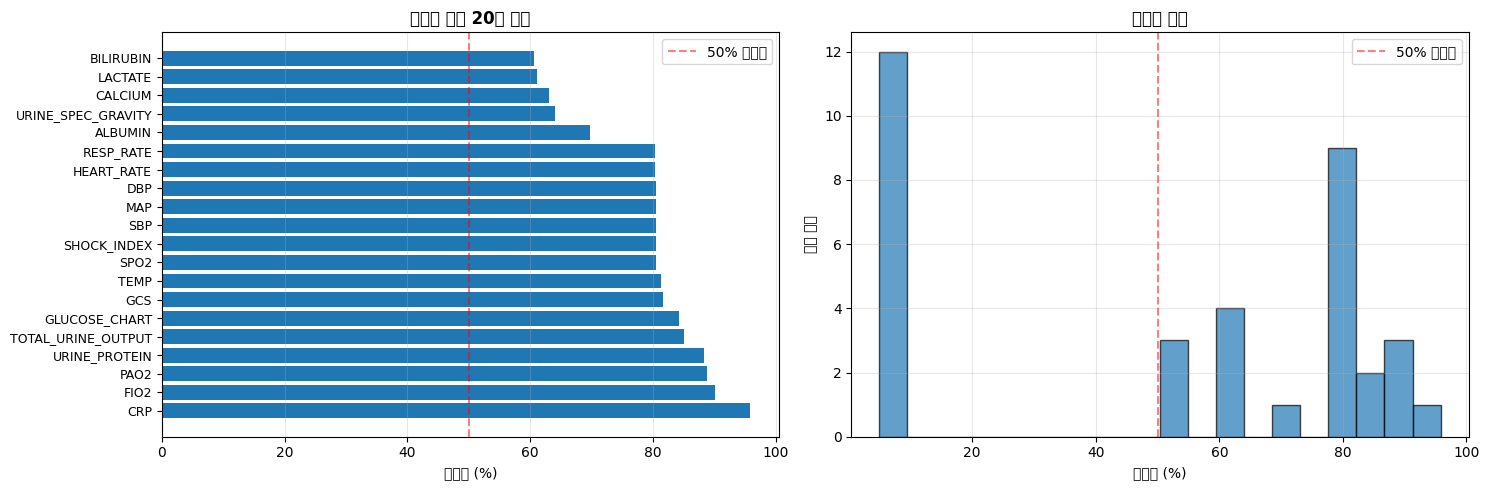


결측률 구간별 변수 개수:
  0-10%: 12개
  10-30%: 0개
  30-50%: 0개
  50-70%: 8개
  70%+: 15개


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 'data' DataFrame이 정의되지 않았으므로 다시 로드합니다.
data = pd.read_csv(f'{base_path}cohort_csv/data.csv')

# =============================================================================
# 3. 결측치 분석
# =============================================================================
print("\n" + "=" * 80)
print("[3] 결측치 분석")
print("=" * 80)

# 결측치 계산
missing_stats = pd.DataFrame({
    '결측수': data.isnull().sum(),
    '결측률(%)': (data.isnull().sum() / len(data) * 100).round(2)
})
missing_stats = missing_stats[missing_stats['결측수'] > 0].sort_values('결측률(%)', ascending=False)

print(f"\n결측치가 있는 변수: {len(missing_stats)}개")
print("\n결측률 상위 20개 변수:")
print(missing_stats.head(20))

# 결측률 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 결측률 막대그래프
if len(missing_stats) > 0:
    top_missing = missing_stats.head(20)
    axes[0].barh(range(len(top_missing)), top_missing['결측률(%)'])
    axes[0].set_yticks(range(len(top_missing)))
    axes[0].set_yticklabels(top_missing.index, fontsize=9)
    axes[0].set_xlabel('결측률 (%)', fontsize=10)
    axes[0].set_title('결측률 상위 20개 변수', fontsize=12, fontweight='bold')
    axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% 기준선')
    axes[0].legend()
    axes[0].grid(axis='x', alpha=0.3)

# 결측률 히스토그램
axes[1].hist(missing_stats['결측률(%)'], bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('결측률 (%)', fontsize=10)
axes[1].set_ylabel('변수 개수', fontsize=10)
axes[1].set_title('결측률 분포', fontsize=12, fontweight='bold')
axes[1].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% 기준선')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

# 결측률 그룹별 분류
missing_categories = {
    '0-10%': (missing_stats['결측률(%)'] <= 10).sum(),
    '10-30%': ((missing_stats['결측률(%)'] > 10) & (missing_stats['결측률(%)'] <= 30)).sum(),
    '30-50%': ((missing_stats['결측률(%)'] > 30) & (missing_stats['결측률(%)'] <= 50)).sum(),
    '50-70%': ((missing_stats['결측률(%)'] > 50) & (missing_stats['결측률(%)'] <= 70)).sum(),
    '70%+': (missing_stats['결측률(%)'] > 70).sum()
}

print("\n결측률 구간별 변수 개수:")
for category, count in missing_categories.items():
    print(f"  {category}: {count}개")

# MISSING_RATIO 변수 분석
# 'base_path'와 'cont_cols'가 정의되어 있지 않아 오류가 발생할 수 있으므로,
# 여기서는 'MISSING_RATIO' 컬럼만 확인합니다.
if 'MISSING_RATIO' in data.columns:
    print("\n환자별 결측률 (MISSING_RATIO) 통계:")
    print(data['MISSING_RATIO'].describe())

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(data['MISSING_RATIO'], bins=50, edgecolor='black', alpha=0.7)
    ax.set_xlabel('환자별 결측률 (%)', fontsize=10)
    ax.set_ylabel('환자 수', fontsize=10)
    ax.set_title('환자별 결측률 분포', fontsize=12, fontweight='bold')
    ax.axvline(x=data['MISSING_RATIO'].median(), color='red', linestyle='--',
               label=f'중앙값: {data["MISSING_RATIO"].median():.1f}%')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('02_patient_missing_ratio.png', dpi=300, bbox_inches='tight')
    plt.show()


[4] 인구통계 분석

나이 분포:
count    43171.000000
mean        58.793542
std         19.639866
min         18.000000
25%         45.000000
50%         60.000000
75%         74.000000
max        100.000000
Name: AGE_AT_ADMISSION, dtype: float64

성별 분포:
GENDER
F    22210
M    20961
Name: count, dtype: int64

성비 (M:F) = 20961 : 22210

패혈증 유무별 나이 차이 검정 (t-test):
  비패혈증 평균: 58.2세
  패혈증 평균: 67.1세
  p-value: 0.0000


/tmp/ipython-input-2662813329.py:71: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2662813329.py:71: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2662813329.py:71: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2662813329.py:71: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2662813329.py:71: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2662813329.py:71: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2662813329.py:71: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

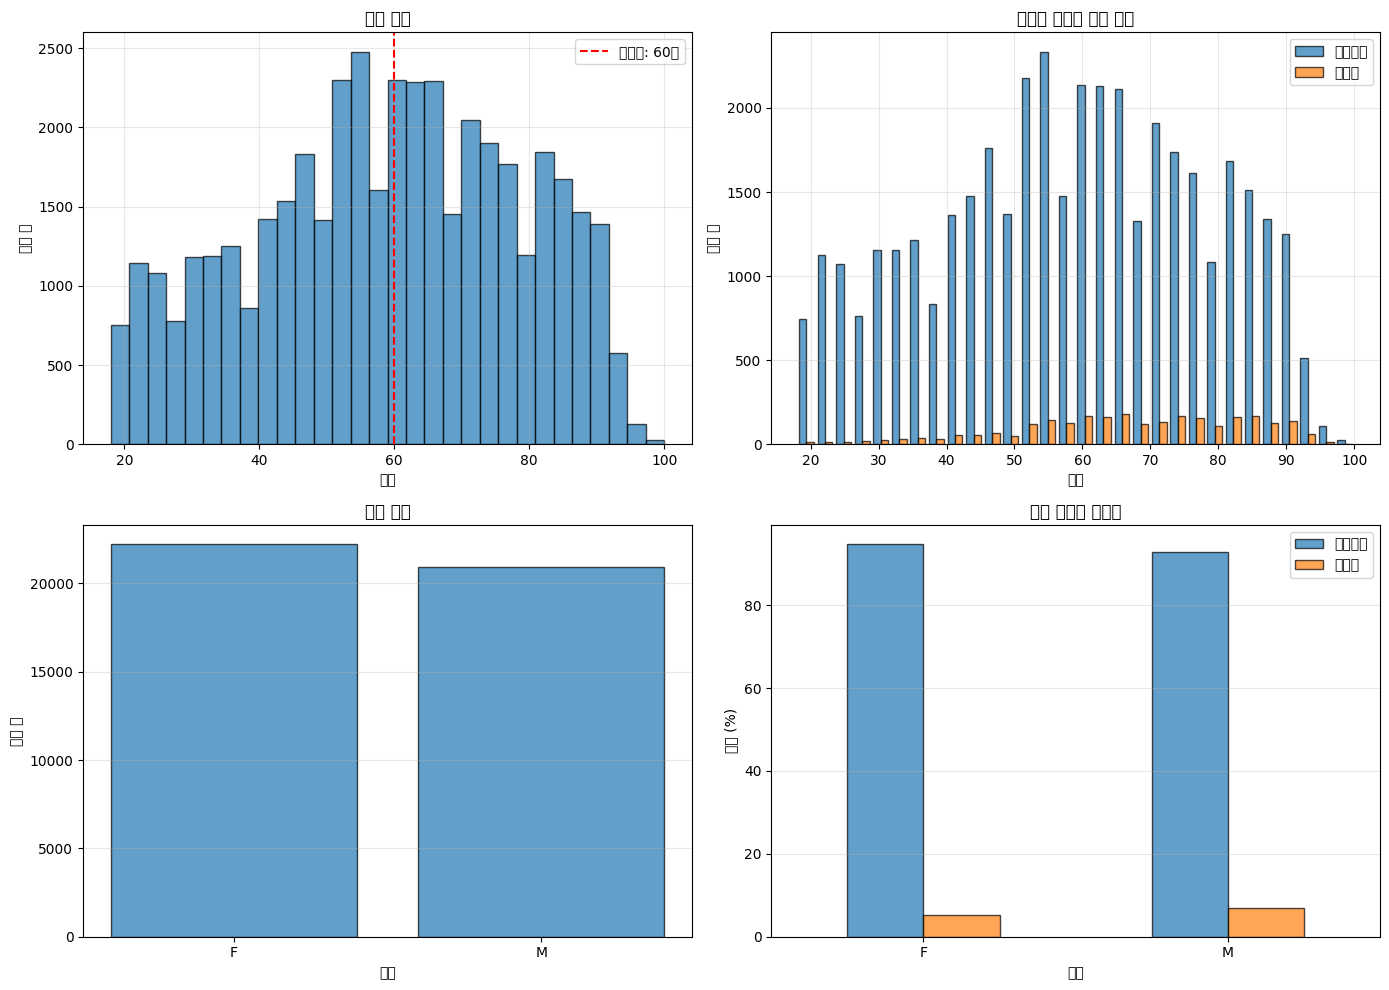

In [ ]:
# =============================================================================
# 4. 인구통계 분석
# =============================================================================
print("\n" + "=" * 80)
print("[4] 인구통계 분석")
print("=" * 80)

# 나이 분포
print("\n나이 분포:")
print(df['AGE_AT_ADMISSION'].describe())

# 성별 분포
if 'GENDER' in df.columns:
    print("\n성별 분포:")
    print(df['GENDER'].value_counts())
    print(f"\n성비 (M:F) = {df['GENDER'].value_counts().get('M', 0)} : {df['GENDER'].value_counts().get('F', 0)}")

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 나이 히스토그램
axes[0, 0].hist(df['AGE_AT_ADMISSION'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('나이', fontsize=10)
axes[0, 0].set_ylabel('환자 수', fontsize=10)
axes[0, 0].set_title('나이 분포', fontsize=12, fontweight='bold')
axes[0, 0].axvline(x=df['AGE_AT_ADMISSION'].median(), color='red', linestyle='--',
                   label=f'중앙값: {df["AGE_AT_ADMISSION"].median():.0f}세')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 패혈증 유무별 나이 분포
if 'SEPSIS' in df.columns:
    sepsis_age = df[df['SEPSIS'] == 1]['AGE_AT_ADMISSION'].dropna()
    non_sepsis_age = df[df['SEPSIS'] == 0]['AGE_AT_ADMISSION'].dropna()

    axes[0, 1].hist([non_sepsis_age, sepsis_age], bins=30,
                    label=['비패혈증', '패혈증'], alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('나이', fontsize=10)
    axes[0, 1].set_ylabel('환자 수', fontsize=10)
    axes[0, 1].set_title('패혈증 유무별 나이 분포', fontsize=12, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # 통계 검정
    t_stat, p_value = stats.ttest_ind(non_sepsis_age, sepsis_age)
    print(f"\n패혈증 유무별 나이 차이 검정 (t-test):")
    print(f"  비패혈증 평균: {non_sepsis_age.mean():.1f}세")
    print(f"  패혈증 평균: {sepsis_age.mean():.1f}세")
    print(f"  p-value: {p_value:.4f}")

# 성별 분포
if 'GENDER' in df.columns:
    gender_counts = df['GENDER'].value_counts()
    axes[1, 0].bar(gender_counts.index, gender_counts.values, edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('성별', fontsize=10)
    axes[1, 0].set_ylabel('환자 수', fontsize=10)
    axes[1, 0].set_title('성별 분포', fontsize=12, fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)

    # 패혈증 유무별 성별 분포
    if 'SEPSIS' in df.columns:
        sepsis_gender = pd.crosstab(df['GENDER'], df['SEPSIS'], normalize='index') * 100
        sepsis_gender.plot(kind='bar', ax=axes[1, 1], edgecolor='black', alpha=0.7)
        axes[1, 1].set_xlabel('성별', fontsize=10)
        axes[1, 1].set_ylabel('비율 (%)', fontsize=10)
        axes[1, 1].set_title('성별 패혈증 발생률', fontsize=12, fontweight='bold')
        axes[1, 1].legend(['비패혈증', '패혈증'])
        axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
        axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('03_demographics.png', dpi=300, bbox_inches='tight')
plt.show()



[6] 혈액검사 분석

혈액검사 기술통계 (상위 10개):
                 count        mean         std   min    25%    50%    75%  \
WBC            40304.0   10.069322    8.791643   0.1    6.6    8.8   11.9   
HB             40304.0   12.199095    2.196590   3.2   10.8   12.4   13.7   
PLATELET       40283.0  252.777872  114.544398   5.0  184.0  238.0  303.0   
LACTATE        16792.0    2.099128    1.653259   0.0    1.2    1.7    2.4   
CREATININE     41023.0    1.288933    1.416654   0.0    0.7    0.9    1.2   
BUN            41002.0   21.683381   17.338538   1.0   12.0   17.0   25.0   
GLUCOSE_CHART   6779.0  168.590980   93.585239  20.0  110.0  139.0  193.0   
GLUCOSE_LAB    40575.0  137.504054   83.589407   5.0   97.0  113.0  145.0   
INR            21340.0    1.433613    0.964120   0.7    1.0    1.1    1.4   
PT             21349.0   15.736698    9.988880   8.3   11.6   12.8   15.1   

                  max  결측률(%)  
WBC             797.4    6.64  
HB               20.0    6.64  
PLATELET       2947.0 

/tmp/ipython-input-2147104617.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
/tmp/ipython-input-2147104617.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
/tmp/ipython-input-2147104617.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
/tmp/ipython-input-2147104617.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = a

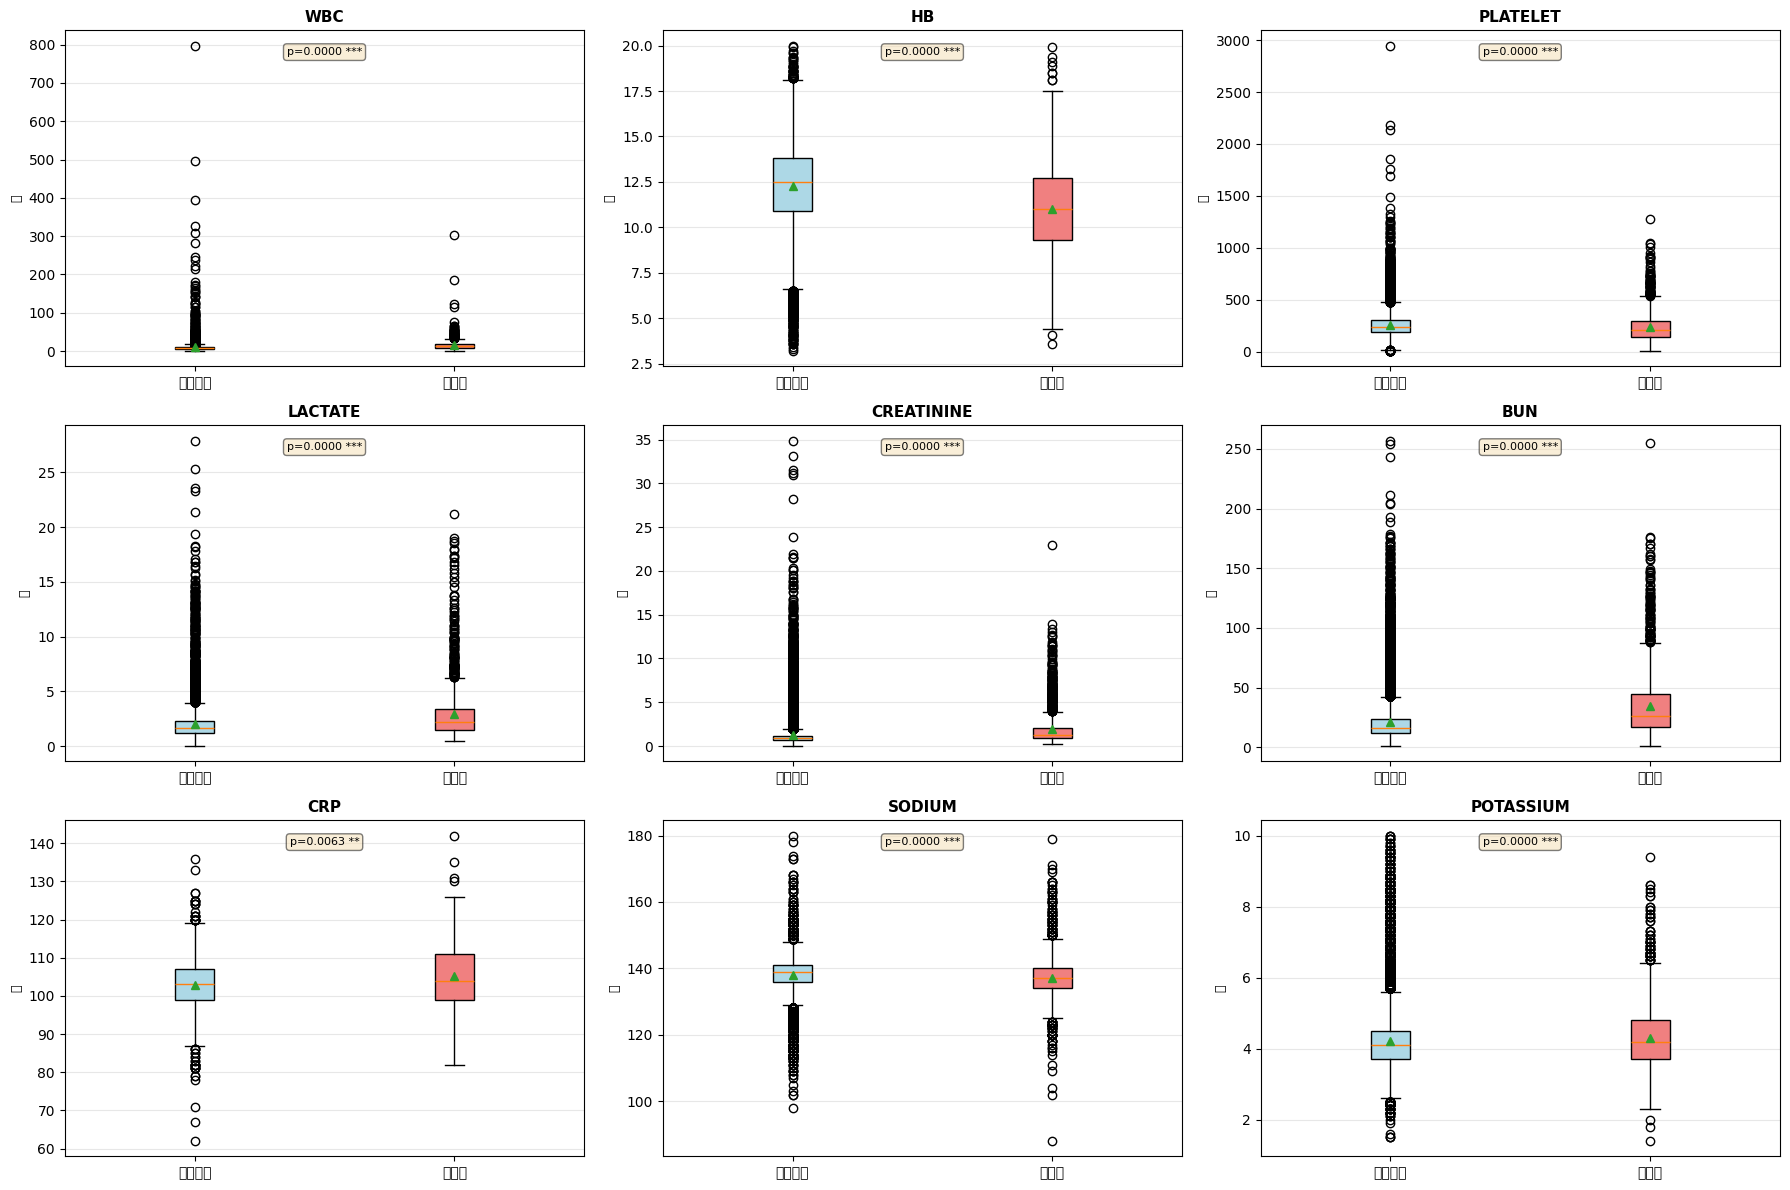

In [ ]:
# =============================================================================
# 6. 혈액검사 분석
# =============================================================================
print("\n" + "=" * 80)
print("[6] 혈액검사 분석")
print("=" * 80)

lab_analysis = df[lab_cols].describe().T
lab_analysis['결측률(%)'] = (df[lab_cols].isnull().sum() / len(df) * 100).round(2)
print("\n혈액검사 기술통계 (상위 10개):")
print(lab_analysis.head(10))

# 주요 혈액검사 항목 시각화
key_labs = ['WBC', 'HB', 'PLATELET', 'LACTATE', 'CREATININE', 'BUN',
            'CRP', 'SODIUM', 'POTASSIUM']
available_key_labs = [col for col in key_labs if col in df.columns and df[col].notna().sum() > 0]

n_labs = len(available_key_labs)
n_rows = (n_labs + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows*4))
axes = axes.flatten() if n_labs > 1 else [axes]

for idx, col in enumerate(available_key_labs):
    ax = axes[idx]

    data_to_plot = [
        df[df['SEPSIS'] == 0][col].dropna(),
        df[df['SEPSIS'] == 1][col].dropna()
    ]

    bp = ax.boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
                    patch_artist=True, showmeans=True)

    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('값', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # 통계 검정
    if len(data_to_plot[0]) > 0 and len(data_to_plot[1]) > 0:
        stat, p = stats.mannwhitneyu(data_to_plot[0], data_to_plot[1], alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax.text(0.5, 0.95, f'p={p:.4f} {sig}',
               transform=ax.transAxes, ha='center', va='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
               fontsize=8)

# 빈 subplot 제거
for idx in range(n_labs, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('05_lab_tests.png', dpi=300, bbox_inches='tight')
plt.show()


[7] 패혈증 관련 주요 지표 분석

SOFA 점수 분석:
              count      mean       std  min  25%  50%  75%   max
SOFA_TOTAL  43171.0  1.609228  2.685576  0.0  0.0  0.0  2.0  20.0

패혈증 유무별 SOFA_TOTAL 점수:

비패혈증:
  평균: 1.40
  중앙값: 0.00
  표준편차: 2.41

패혈증:
  평균: 4.82
  중앙값: 4.00
  표준편차: 4.16


/tmp/ipython-input-3598541992.py:59: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3598541992.py:59: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3598541992.py:59: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3598541992.py:59: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3598541992.py:59: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3598541992.py:59: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3598541992.py:59: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

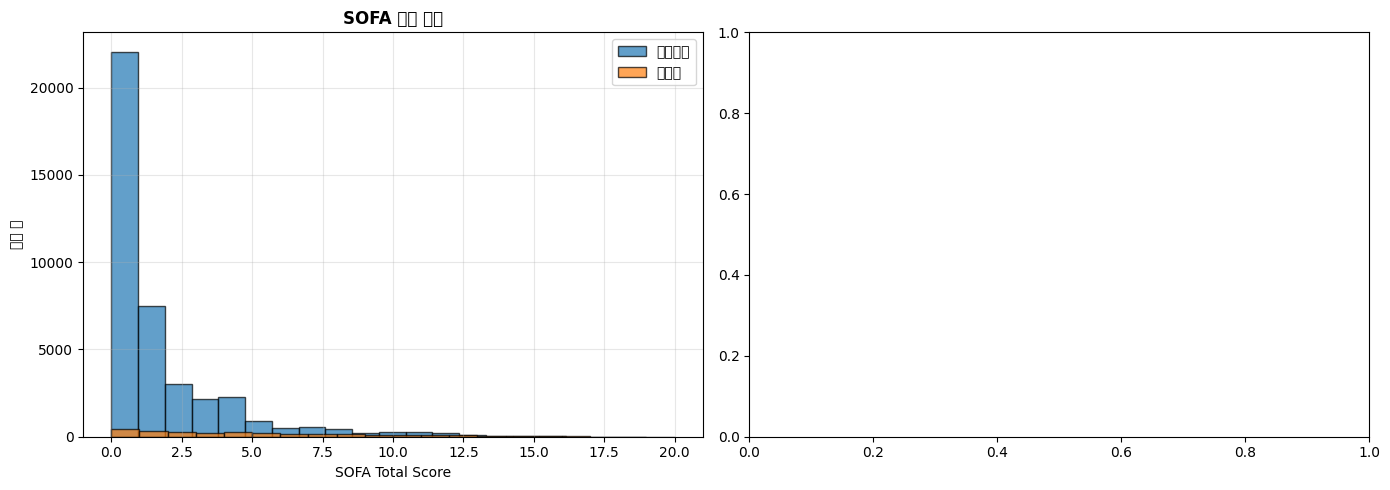

/tmp/ipython-input-3598541992.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
/tmp/ipython-input-3598541992.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
/tmp/ipython-input-3598541992.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
/tmp/ipython-input-3598541992.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be drop

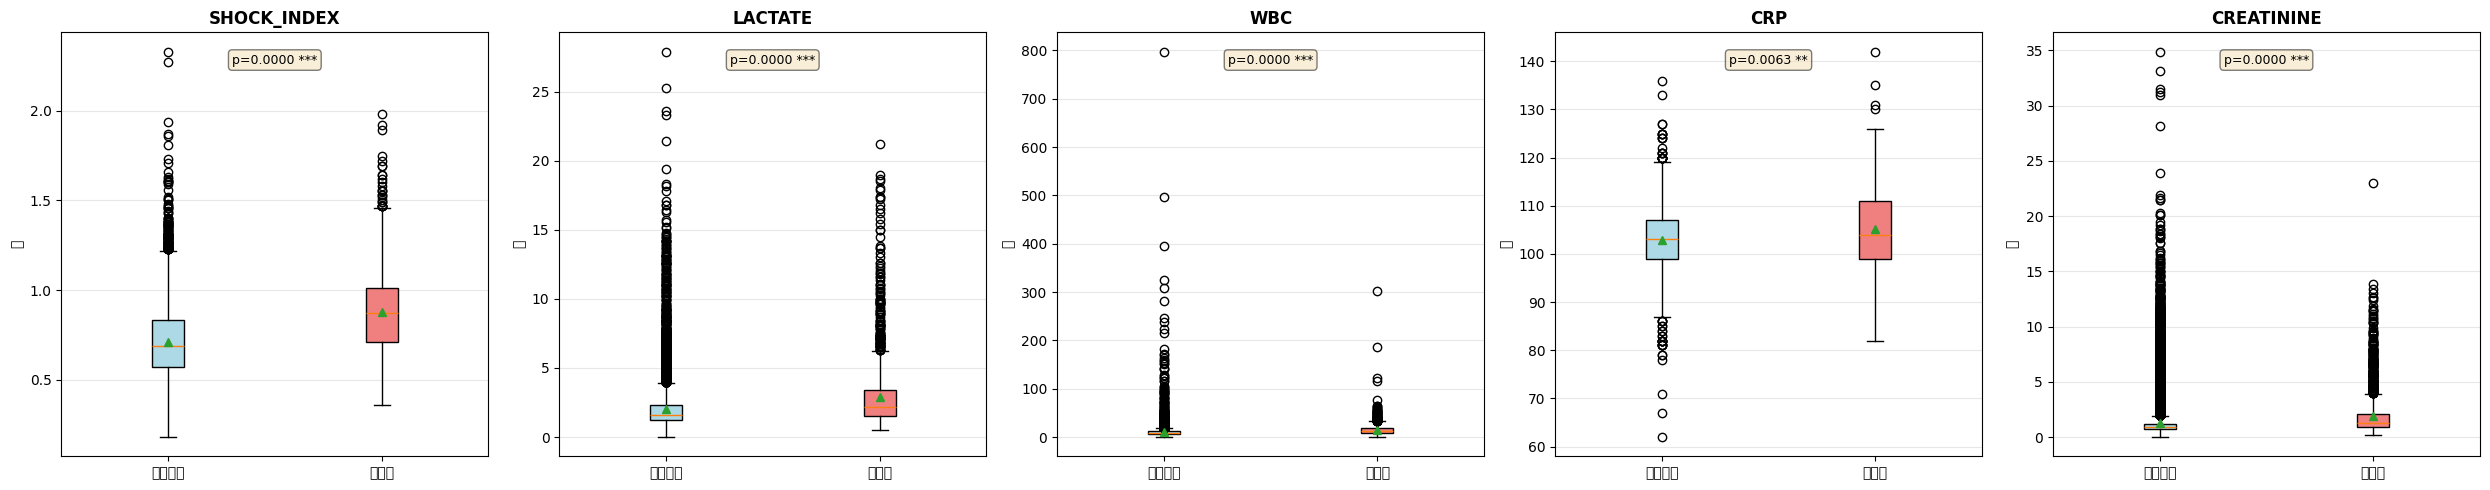

In [ ]:
# =============================================================================
# 7. 패혈증 예측 관련 주요 지표 분석
# =============================================================================
print("\n" + "=" * 80)
print("[7] 패혈증 관련 주요 지표 분석")
print("=" * 80)

# SOFA 점수 분석
if len(sofa_cols) > 0:
    print("\nSOFA 점수 분석:")
    sofa_stats = df[sofa_cols].describe().T
    print(sofa_stats)

    # 패혈증 유무별 SOFA 점수
    if 'SOFA_TOTAL' in df.columns:
        print("\n패혈증 유무별 SOFA_TOTAL 점수:")
        for sepsis_status in [0, 1]:
            label = "비패혈증" if sepsis_status == 0 else "패혈증"
            sofa_values = df[df['SEPSIS'] == sepsis_status]['SOFA_TOTAL'].dropna()
            print(f"\n{label}:")
            print(f"  평균: {sofa_values.mean():.2f}")
            print(f"  중앙값: {sofa_values.median():.2f}")
            print(f"  표준편차: {sofa_values.std():.2f}")

        # 시각화
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # SOFA 점수 분포
        df[df['SEPSIS'] == 0]['SOFA_TOTAL'].hist(ax=axes[0], bins=20, alpha=0.7,
                                                   label='비패혈증', edgecolor='black')
        df[df['SEPSIS'] == 1]['SOFA_TOTAL'].hist(ax=axes[0], bins=20, alpha=0.7,
                                                   label='패혈증', edgecolor='black')
        axes[0].set_xlabel('SOFA Total Score', fontsize=10)
        axes[0].set_ylabel('환자 수', fontsize=10)
        axes[0].set_title('SOFA 점수 분포', fontsize=12, fontweight='bold')
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # SOFA 구성요소 비교
        sofa_components = [col for col in sofa_cols if col != 'SOFA_TOTAL']
        if len(sofa_components) > 0:
            sepsis_sofa = df[df['SEPSIS'] == 1][sofa_components].mean()
            non_sepsis_sofa = df[df['SEPSIS'] == 0][sofa_components].mean()

            x = np.arange(len(sofa_components))
            width = 0.35

            axes[1].bar(x - width/2, non_sepsis_sofa, width, label='비패혈증', alpha=0.7)
            axes[1].bar(x + width/2, sepsis_sofa, width, label='패혈증', alpha=0.7)
            axes[1].set_xlabel('SOFA 구성요소', fontsize=10)
            axes[1].set_ylabel('평균 점수', fontsize=10)
            axes[1].set_title('SOFA 구성요소별 평균 점수', fontsize=12, fontweight='bold')
            axes[1].set_xticks(x)
            axes[1].set_xticklabels([col.replace('SOFA_', '') for col in sofa_components],
                                   rotation=45, ha='right', fontsize=9)
            axes[1].legend()
            axes[1].grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.savefig('06_sofa_scores.png', dpi=300, bbox_inches='tight')
        plt.show()

# Shock Index, Lactate 등 주요 지표
key_indicators = ['SHOCK_INDEX', 'LACTATE', 'WBC', 'CRP', 'CREATININE']
available_indicators = [col for col in key_indicators if col in df.columns]

if len(available_indicators) > 0:
    fig, axes = plt.subplots(1, len(available_indicators), figsize=(5*len(available_indicators), 5))
    if len(available_indicators) == 1:
        axes = [axes]

    for idx, col in enumerate(available_indicators):
        data_to_plot = [
            df[df['SEPSIS'] == 0][col].dropna(),
            df[df['SEPSIS'] == 1][col].dropna()
        ]

        bp = axes[idx].boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
                               patch_artist=True, showmeans=True)

        colors = ['lightblue', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)

        axes[idx].set_title(col, fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('값', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)

        # 통계 검정
        if len(data_to_plot[0]) > 0 and len(data_to_plot[1]) > 0:
            stat, p = stats.mannwhitneyu(data_to_plot[0], data_to_plot[1], alternative='two-sided')
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            axes[idx].text(0.5, 0.95, f'p={p:.4f} {sig}',
                          transform=axes[idx].transAxes, ha='center', va='top',
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                          fontsize=9)

    plt.tight_layout()
    plt.savefig('07_key_indicators.png', dpi=300, bbox_inches='tight')
    plt.show()



[8] 상관관계 분석

상관관계 분석 대상 변수: 15개

SEPSIS와의 상관관계 (상위 20개):
SOFA_TOTAL          0.306416
BUN                 0.181982
WBC                 0.125806
AGE_AT_ADMISSION    0.108733
CREATININE          0.105530
ANION_GAP_APPROX    0.100722
BUN_CR_RATIO        0.082789
GLUCOSE_LAB         0.072752
POTASSIUM           0.031419
CHLORIDE            0.013893
PLATELET           -0.036713
SODIUM             -0.043145
HB                 -0.128701
BICARBONATE        -0.156047
Name: SEPSIS, dtype: float64

SEPSIS와의 상관관계 (하위 20개):
SOFA_TOTAL          0.306416
BUN                 0.181982
WBC                 0.125806
AGE_AT_ADMISSION    0.108733
CREATININE          0.105530
ANION_GAP_APPROX    0.100722
BUN_CR_RATIO        0.082789
GLUCOSE_LAB         0.072752
POTASSIUM           0.031419
CHLORIDE            0.013893
PLATELET           -0.036713
SODIUM             -0.043145
HB                 -0.128701
BICARBONATE        -0.156047
Name: SEPSIS, dtype: float64


/tmp/ipython-input-2717485123.py:53: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2717485123.py:53: UserWarning: Glyph 54792 (\N{HANGUL SYLLABLE HYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2717485123.py:53: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2717485123.py:53: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2717485123.py:53: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2717485123.py:53: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2717485123.py:53: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_lay

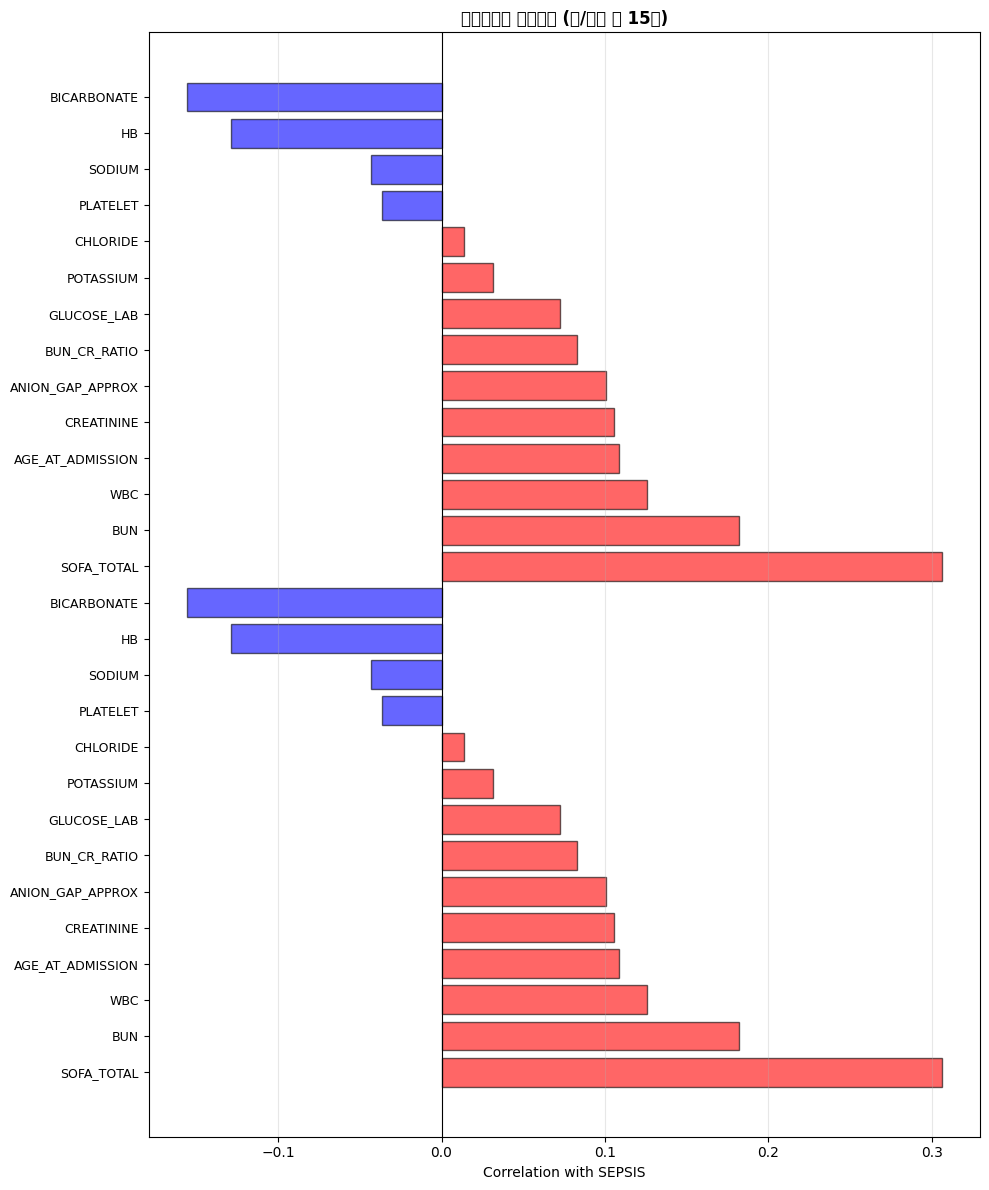

In [ ]:
# =============================================================================
# 8. 상관관계 분석
# =============================================================================
print("\n" + "=" * 80)
print("[8] 상관관계 분석")
print("=" * 80)

# 수치형 변수만 선택
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# ID, outcome 제외
numeric_cols = [col for col in numeric_cols if col not in id_cols + ['HOSPITAL_EXPIRE_FLAG']]

# 결측률 50% 이하인 변수만 사용
# low_missing_cols에는 이미 'SEPSIS'가 포함되어 있으므로,
# 상관관계 계산 시 'SEPSIS' 컬럼을 중복으로 추가하지 않도록 수정합니다.
low_missing_cols = [col for col in numeric_cols
                    if df[col].isnull().sum() / len(df) < 0.5]

print(f"\n상관관계 분석 대상 변수: {len(low_missing_cols)}개")

# Target과의 상관관계
if 'SEPSIS' in df.columns:
    # low_missing_cols에는 이미 'SEPSIS'가 포함되어 있으므로 그대로 사용합니다.
    # .corr() 결과에서 'SEPSIS' 열을 선택하면 Series가 됩니다.
    correlations = df[low_missing_cols].corr()['SEPSIS']

    # 'SEPSIS' 자신과의 상관관계 (항상 1)는 제외합니다.
    correlations = correlations.drop('SEPSIS', errors='ignore') # errors='ignore'를 추가하여 'SEPSIS'가 없는 경우에도 에러 없이 처리

    # 상관관계 값을 기준으로 내림차순 정렬
    correlations = correlations.sort_values(ascending=False)

    print("\nSEPSIS와의 상관관계 (상위 20개):")
    print(correlations.head(20))

    print("\nSEPSIS와의 상관관계 (하위 20개):")
    print(correlations.tail(20))

    # 시각화
    fig, ax = plt.subplots(figsize=(10, 12))
    top_n = 30
    top_corr = pd.concat([correlations.head(top_n//2), correlations.tail(top_n//2)])

    colors = ['red' if x > 0 else 'blue' for x in top_corr.values]
    ax.barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.6, edgecolor='black')
    ax.set_yticks(range(len(top_corr)))
    ax.set_yticklabels(top_corr.index, fontsize=9)
    ax.set_xlabel('Correlation with SEPSIS', fontsize=10)
    ax.set_title('패혈증과의 상관관계 (상/하위 각 15개)', fontsize=12, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('08_correlation_with_sepsis.png', dpi=300, bbox_inches='tight')
    plt.show()

## URINE_PROTEIN (소변 단백) 분포 분석


URINE_PROTEIN 기술통계 (전체):
count    43171.000000
mean        72.743785
std         54.570096
min      -1353.906631
25%         54.465723
50%         68.541046
75%         81.546685
max        600.000000
Name: URINE_PROTEIN, dtype: float64

URINE_PROTEIN 결측치: 0개 (0.00%) 


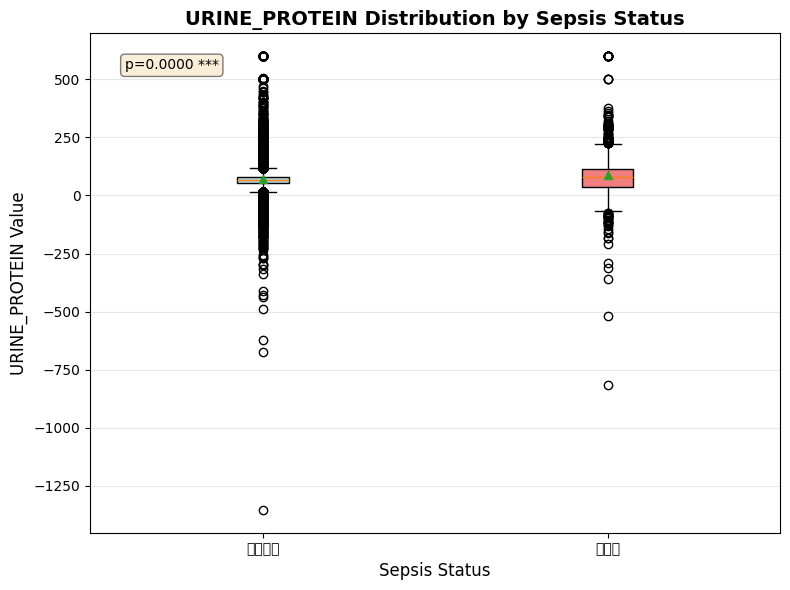

✅ URINE_PROTEIN 박스플롯 저장: urine_protein_boxplot.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# URINE_PROTEIN 컬럼 존재 여부 확인 및 데이터 추출
# df 대신 df_mice_imputed를 사용하여 SEPSIS 컬럼이 존재하는지 확인
if 'URINE_PROTEIN' in df_mice_imputed.columns:
    print(f"\nURINE_PROTEIN 기술통계 (전체):\n{df_mice_imputed['URINE_PROTEIN'].describe()}")

    # URINE_PROTEIN의 결측치 확인
    missing_urine_protein = df_mice_imputed['URINE_PROTEIN'].isnull().sum()
    print(f"\nURINE_PROTEIN 결측치: {missing_urine_protein}개 ({missing_urine_protein / len(df_mice_imputed) * 100:.2f}%) ")

    # 패혈증 유무에 따른 URINE_PROTEIN 분포 시각화
    plt.figure(figsize=(8, 6))

    data_to_plot = [
        df_mice_imputed[df_mice_imputed['SEPSIS'] == 0]['URINE_PROTEIN'].dropna(),
        df_mice_imputed[df_mice_imputed['SEPSIS'] == 1]['URINE_PROTEIN'].dropna()
    ]

    # 데이터가 충분한 경우에만 박스플롯 그리기
    if len(data_to_plot[0]) > 0 or len(data_to_plot[1]) > 0:
        bp = plt.boxplot(data_to_plot, labels=['비패혈증', '패혈증'],
                         patch_artist=True, showmeans=True)

        colors = ['lightblue', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)

        plt.title('URINE_PROTEIN Distribution by Sepsis Status', fontsize=14, fontweight='bold')
        plt.xlabel('Sepsis Status', fontsize=12)
        plt.ylabel('URINE_PROTEIN Value', fontsize=12)
        plt.grid(axis='y', alpha=0.3)

        # 통계 검정
        if len(data_to_plot[0]) > 0 and len(data_to_plot[1]) > 0:
            stat, p = stats.mannwhitneyu(data_to_plot[0], data_to_plot[1], alternative='two-sided')
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            plt.text(0.05, 0.95, f'p={p:.4f} {sig}',
                       transform=plt.gca().transAxes, ha='left', va='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                       fontsize=10)
    else:
        print("URINE_PROTEIN 데이터를 시각화하기에 충분한 유효한 관측치가 없습니다.")

    plt.tight_layout()
    plt.savefig('urine_protein_boxplot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ URINE_PROTEIN 박스플롯 저장: urine_protein_boxplot.png")
else:
    print("데이터프레임에 'URINE_PROTEIN' 컬럼이 존재하지 않습니다.")


In [ ]:
# =============================================================================
# 9. 요약 및 권장사항
# =============================================================================
print("\n" + "=" * 80)
print("[9] EDA 요약 및 모델링 권장사항")
print("=" * 80)

print("\n📊 데이터 현황:")
print(f"  • 총 환자 수: {len(df):,}명")
print(f"  • 패혈증 발생률: {df['SEPSIS'].mean()*100:.2f}%")
print(f"  • 전체 변수 수: {len(df.columns)}개")
print(f"  • 수치형 변수: {len(numeric_cols)}개")

print("\n⚠️ 결측치 이슈:")
print(f"  • 결측치 있는 변수: {len(missing_stats)}개")
print(f"  • 결측률 50% 이상: {(missing_stats['결측률(%)'] > 50).sum()}개")
print(f"  • 결측률 70% 이상: {(missing_stats['결측률(%)'] > 70).sum()}개")

print("\n💡 모델링 권장사항:")
print("\n1. 변수 선택:")
print("   - 결측률 50% 이상 변수는 제외 검토")
print("   - SOFA 점수 변수들은 패혈증 진단에 이미 사용되므로 제외 고려")
print("   - 계산된 변수(SHOCK_INDEX 등)와 원본 변수(HEART_RATE, SBP 등) 중복 체크")

print("\n2. 결측치 처리:")
print("   - 활력징후: 의학적 정상값으로 대체 또는 중앙값 사용")
print("   - 혈액검사: Multiple Imputation 또는 MICE 알고리즘 고려")
print("   - 결측 여부 자체를 피처로 활용 (missing indicator)")

print("\n3. 이상치 처리:")
print("   - IQR 또는 도메인 지식 기반 범위 설정")
print("   - Winsorization (극단값 제한) 고려")
print("   - 로그 변환으로 분포 정규화")

print("\n4. 피처 엔지니어링:")
print("   - 활력징후 간 조합 (예: MAP, Shock Index)")
print("   - 비율 변수 (예: BUN/Cr ratio - 이미 존재)")
print("   - 범주화 (예: 나이 그룹, 중증도 등급)")

print("\n5. 클래스 불균형 처리:")
imbalance_ratio = (df['SEPSIS'] == 0).sum() / (df['SEPSIS'] == 1).sum()
print(f"   - 불균형 비율: {imbalance_ratio:.1f}:1")
print("   - SMOTE, ADASYN 등 오버샘플링 기법 고려")
print("   - Class weight 조정")
print("   - Stratified K-Fold 사용")

print("\n6. 모델 선택:")
print("   - XGBoost, LightGBM: 결측치 처리 가능, 해석 가능")
print("   - Random Forest: 강건한 성능")
print("   - Logistic Regression: 베이스라인, 해석 용이")
print("   - Neural Network: 복잡한 패턴 학습")

print("\n7. 평가 지표:")
print("   - AUROC, AUPRC (불균형 데이터에 적합)")
print("   - Sensitivity, Specificity")
print("   - F1-score, F2-score (재현율 중시)")

print("\n✅ EDA 완료!")
print("=" * 80)



[9] EDA 요약 및 모델링 권장사항

📊 데이터 현황:
  • 총 환자 수: 43,171명
  • 패혈증 발생률: 6.17%
  • 전체 변수 수: 43개
  • 수치형 변수: 38개

⚠️ 결측치 이슈:
  • 결측치 있는 변수: 35개
  • 결측률 50% 이상: 23개
  • 결측률 70% 이상: 15개

💡 모델링 권장사항:

1. 변수 선택:
   - 결측률 50% 이상 변수는 제외 검토
   - SOFA 점수 변수들은 패혈증 진단에 이미 사용되므로 제외 고려
   - 계산된 변수(SHOCK_INDEX 등)와 원본 변수(HEART_RATE, SBP 등) 중복 체크

2. 결측치 처리:
   - 활력징후: 의학적 정상값으로 대체 또는 중앙값 사용
   - 혈액검사: Multiple Imputation 또는 MICE 알고리즘 고려
   - 결측 여부 자체를 피처로 활용 (missing indicator)

3. 이상치 처리:
   - IQR 또는 도메인 지식 기반 범위 설정
   - Winsorization (극단값 제한) 고려
   - 로그 변환으로 분포 정규화

4. 피처 엔지니어링:
   - 활력징후 간 조합 (예: MAP, Shock Index)
   - 비율 변수 (예: BUN/Cr ratio - 이미 존재)
   - 범주화 (예: 나이 그룹, 중증도 등급)

5. 클래스 불균형 처리:
   - 불균형 비율: 15.2:1
   - SMOTE, ADASYN 등 오버샘플링 기법 고려
   - Class weight 조정
   - Stratified K-Fold 사용

6. 모델 선택:
   - XGBoost, LightGBM: 결측치 처리 가능, 해석 가능
   - Random Forest: 강건한 성능
   - Logistic Regression: 베이스라인, 해석 용이
   - Neural Network: 복잡한 패턴 학습

7. 평가 지표:
   - AUROC, AUPRC (불균형 데이터에 적합)
   - Sensitivity, Speci

# DATA_5_RemovingOutlier.csv

In [ ]:
##### 이상치 정리 #####

import pandas as pd
import numpy as np

base_path = '/content/drive/MyDrive/ColabNotebooks/'
df = pd.read_csv(f'{base_path}cohort_csv/data_gcslast.csv')

def remove_outliers_mimic(df):
    """
    제공된 비정상값 기준(절대 NA) 이미지 및 수행계획서를 바탕으로
    이상치를 NaN으로 치환하는 함수
    """
    # 원본 데이터 보존을 위해 복사본 생성
    clean_df = df.copy()

    # --- Layer 1: 활력징후 및 기초 정보 (icu.chartevents) ---
    # 심박수 (HEART_RATE): <20, >250 bpm
    clean_df.loc[(clean_df['HEART_RATE'] < 20) | (clean_df['HEART_RATE'] > 250), 'HEART_RATE'] = np.nan

    # 수축기 혈압 (SBP): <50, >300 mmHg
    clean_df.loc[(clean_df['SBP'] < 50) | (clean_df['SBP'] > 300), 'SBP'] = np.nan

    # 이완기 혈압 (DBP): <30, >200 mmHg
    clean_df.loc[(clean_df['DBP'] < 30) | (clean_df['DBP'] > 200), 'DBP'] = np.nan

    # 평균 동맥압 (MAP): <30, >200 mmHg
    clean_df.loc[(clean_df['MAP'] < 30) | (clean_df['MAP'] > 200), 'MAP'] = np.nan

    # 호흡수 (RESP_RATE): <5, >80 /min
    clean_df.loc[(clean_df['RESP_RATE'] < 5) | (clean_df['RESP_RATE'] > 80), 'RESP_RATE'] = np.nan

    # 체온 (TEMP): <30, >43 °C
    clean_df.loc[(clean_df['TEMP'] < 30) | (clean_df['TEMP'] > 43), 'TEMP'] = np.nan

    # 산소포화도 (SPO2): <50, >100%
    clean_df.loc[(clean_df['SPO2'] < 50) | (clean_df['SPO2'] > 100), 'SPO2'] = np.nan

    # FiO2: <21, >100 (21-100% 범위를 벗어나는 경우)
    clean_df.loc[(clean_df['FIO2'] < 21) | (clean_df['FIO2'] > 100), 'FIO2'] = np.nan

    # GCS: <3, >15 총점
    clean_df.loc[(clean_df['GCS'] < 3) | (clean_df['GCS'] > 15), 'GCS'] = np.nan

    # --- Layer 2: 혈액검사 및 소변검사 (hosp.labevents / icu.outputevents) ---
    # WBC: <0.1, >200 x10^3/µL
    clean_df.loc[(clean_df['WBC'] < 0.1) | (clean_df['WBC'] > 200), 'WBC'] = np.nan

    # Hb: <3, >25 g/dL
    clean_df.loc[(clean_df['HB'] < 3) | (clean_df['HB'] > 25), 'HB'] = np.nan

    # PLATELET: <1, >2000 x10^3/µL
    clean_df.loc[(clean_df['PLATELET'] < 1) | (clean_df['PLATELET'] > 2000), 'PLATELET'] = np.nan

    # LACTATE: <0.1, >30 mmol/L
    clean_df.loc[(clean_df['LACTATE'] < 0.1) | (clean_df['LACTATE'] > 30), 'LACTATE'] = np.nan

    # CREATININE: <0.1, >20 mg/dL
    clean_df.loc[(clean_df['CREATININE'] < 0.1) | (clean_df['CREATININE'] > 20), 'CREATININE'] = np.nan

    # BUN: <1, >300 mg/dL
    clean_df.loc[(clean_df['BUN'] < 1) | (clean_df['BUN'] > 300), 'BUN'] = np.nan

    # GLUCOSE: <20, >1000 mg/dL (Chart 및 Lab 공통 적용)
    glucose_cols = ['GLUCOSE_CHART', 'GLUCOSE_LAB']
    for col in glucose_cols:
        if col in clean_df.columns:
            clean_df.loc[(clean_df[col] < 20) | (clean_df[col] > 1000), col] = np.nan

    # 응고 수치 (INR, PT, PTT)
    clean_df.loc[(clean_df['INR'] < 0.5) | (clean_df['INR'] > 20), 'INR'] = np.nan
    clean_df.loc[(clean_df['PT'] < 5) | (clean_df['PT'] > 100), 'PT'] = np.nan
    clean_df.loc[(clean_df['PTT'] < 10) | (clean_df['PTT'] > 200), 'PTT'] = np.nan

    # 전해질 (Sodium, Potassium, Chloride, Bicarbonate)
    clean_df.loc[(clean_df['SODIUM'] < 110) | (clean_df['SODIUM'] > 180), 'SODIUM'] = np.nan
    clean_df.loc[(clean_df['POTASSIUM'] < 2.0) | (clean_df['POTASSIUM'] > 8.0), 'POTASSIUM'] = np.nan
    clean_df.loc[(clean_df['CHLORIDE'] < 70) | (clean_df['CHLORIDE'] > 140), 'CHLORIDE'] = np.nan
    clean_df.loc[(clean_df['BICARBONATE'] < 5) | (clean_df['BICARBONATE'] > 50), 'BICARBONATE'] = np.nan

    # 기타 Lab 수치 (Bilirubin, PaO2, CRP, Albumin, Calcium)
    clean_df.loc[(clean_df['BILIRUBIN'] < 0) | (clean_df['BILIRUBIN'] > 50), 'BILIRUBIN'] = np.nan
    clean_df.loc[(clean_df['PAO2'] < 20) | (clean_df['PAO2'] > 600), 'PAO2'] = np.nan
    clean_df.loc[(clean_df['CRP'] < 0) | (clean_df['CRP'] > 500), 'CRP'] = np.nan
    clean_df.loc[(clean_df['ALBUMIN'] < 1.0) | (clean_df['ALBUMIN'] > 6.0), 'ALBUMIN'] = np.nan
    clean_df.loc[(clean_df['CALCIUM'] < 5) | (clean_df['CALCIUM'] > 15), 'CALCIUM'] = np.nan

    # 소변 검사 (Specific Gravity, Output)
    # URINE_PROTEIN: 음수 제거 및 임상적 범주 외 값(예: >500) 제거
    clean_df.loc[(clean_df['URINE_PROTEIN'] < 0) | (clean_df['URINE_PROTEIN'] > 500), 'URINE_PROTEIN'] = np.nan
    clean_df.loc[(clean_df['URINE_SPEC_GRAVITY'] < 1.000) | (clean_df['URINE_SPEC_GRAVITY'] > 1.050), 'URINE_SPEC_GRAVITY'] = np.nan
    clean_df.loc[clean_df['TOTAL_URINE_OUTPUT'] < 0, 'TOTAL_URINE_OUTPUT'] = np.nan

    # --- Layer 3: 파생 지표 및 중증도 (Calculated) ---
    clean_df.loc[(clean_df['SHOCK_INDEX'] < 0) | (clean_df['SHOCK_INDEX'] > 5), 'SHOCK_INDEX'] = np.nan
    clean_df.loc[(clean_df['ANION_GAP_APPROX'] < 0) | (clean_df['ANION_GAP_APPROX'] > 50), 'ANION_GAP_APPROX'] = np.nan
    clean_df.loc[(clean_df['BUN_CR_RATIO'] < 0) | (clean_df['BUN_CR_RATIO'] > 200), 'BUN_CR_RATIO'] = np.nan
    clean_df.loc[(clean_df['SOFA_TOTAL'] < 0) | (clean_df['SOFA_TOTAL'] > 24), 'SOFA_TOTAL'] = np.nan

    return clean_df

# 사용 예시:
df_cleaned = remove_outliers_mimic(df)
df_cleaned.head()
df_cleaned.to_csv('data_after_outlier.csv', index=False, encoding='utf-8-sig')



===== 결측치 현황 요약 =====
                    Missing Count  Percentage (%)
CRP                         41361       95.807371
FIO2                        38938       90.194807
PAO2                        38337       88.802668
URINE_PROTEIN               38211       88.510806
TOTAL_URINE_OUTPUT          36705       85.022353
GLUCOSE_CHART               36392       84.297329
GCS                         35266       81.689097
TEMP                        35101       81.306896
SPO2                        34747       80.486901
SHOCK_INDEX                 34738       80.466054
DBP                         34738       80.466054
SBP                         34731       80.449839
MAP                         34730       80.447523
HEART_RATE                  34695       80.366450
RESP_RATE                   34677       80.324755
ALBUMIN                     30090       69.699567
URINE_SPEC_GRAVITY          27624       63.987399
CALCIUM                     27235       63.086331
LACTATE                     

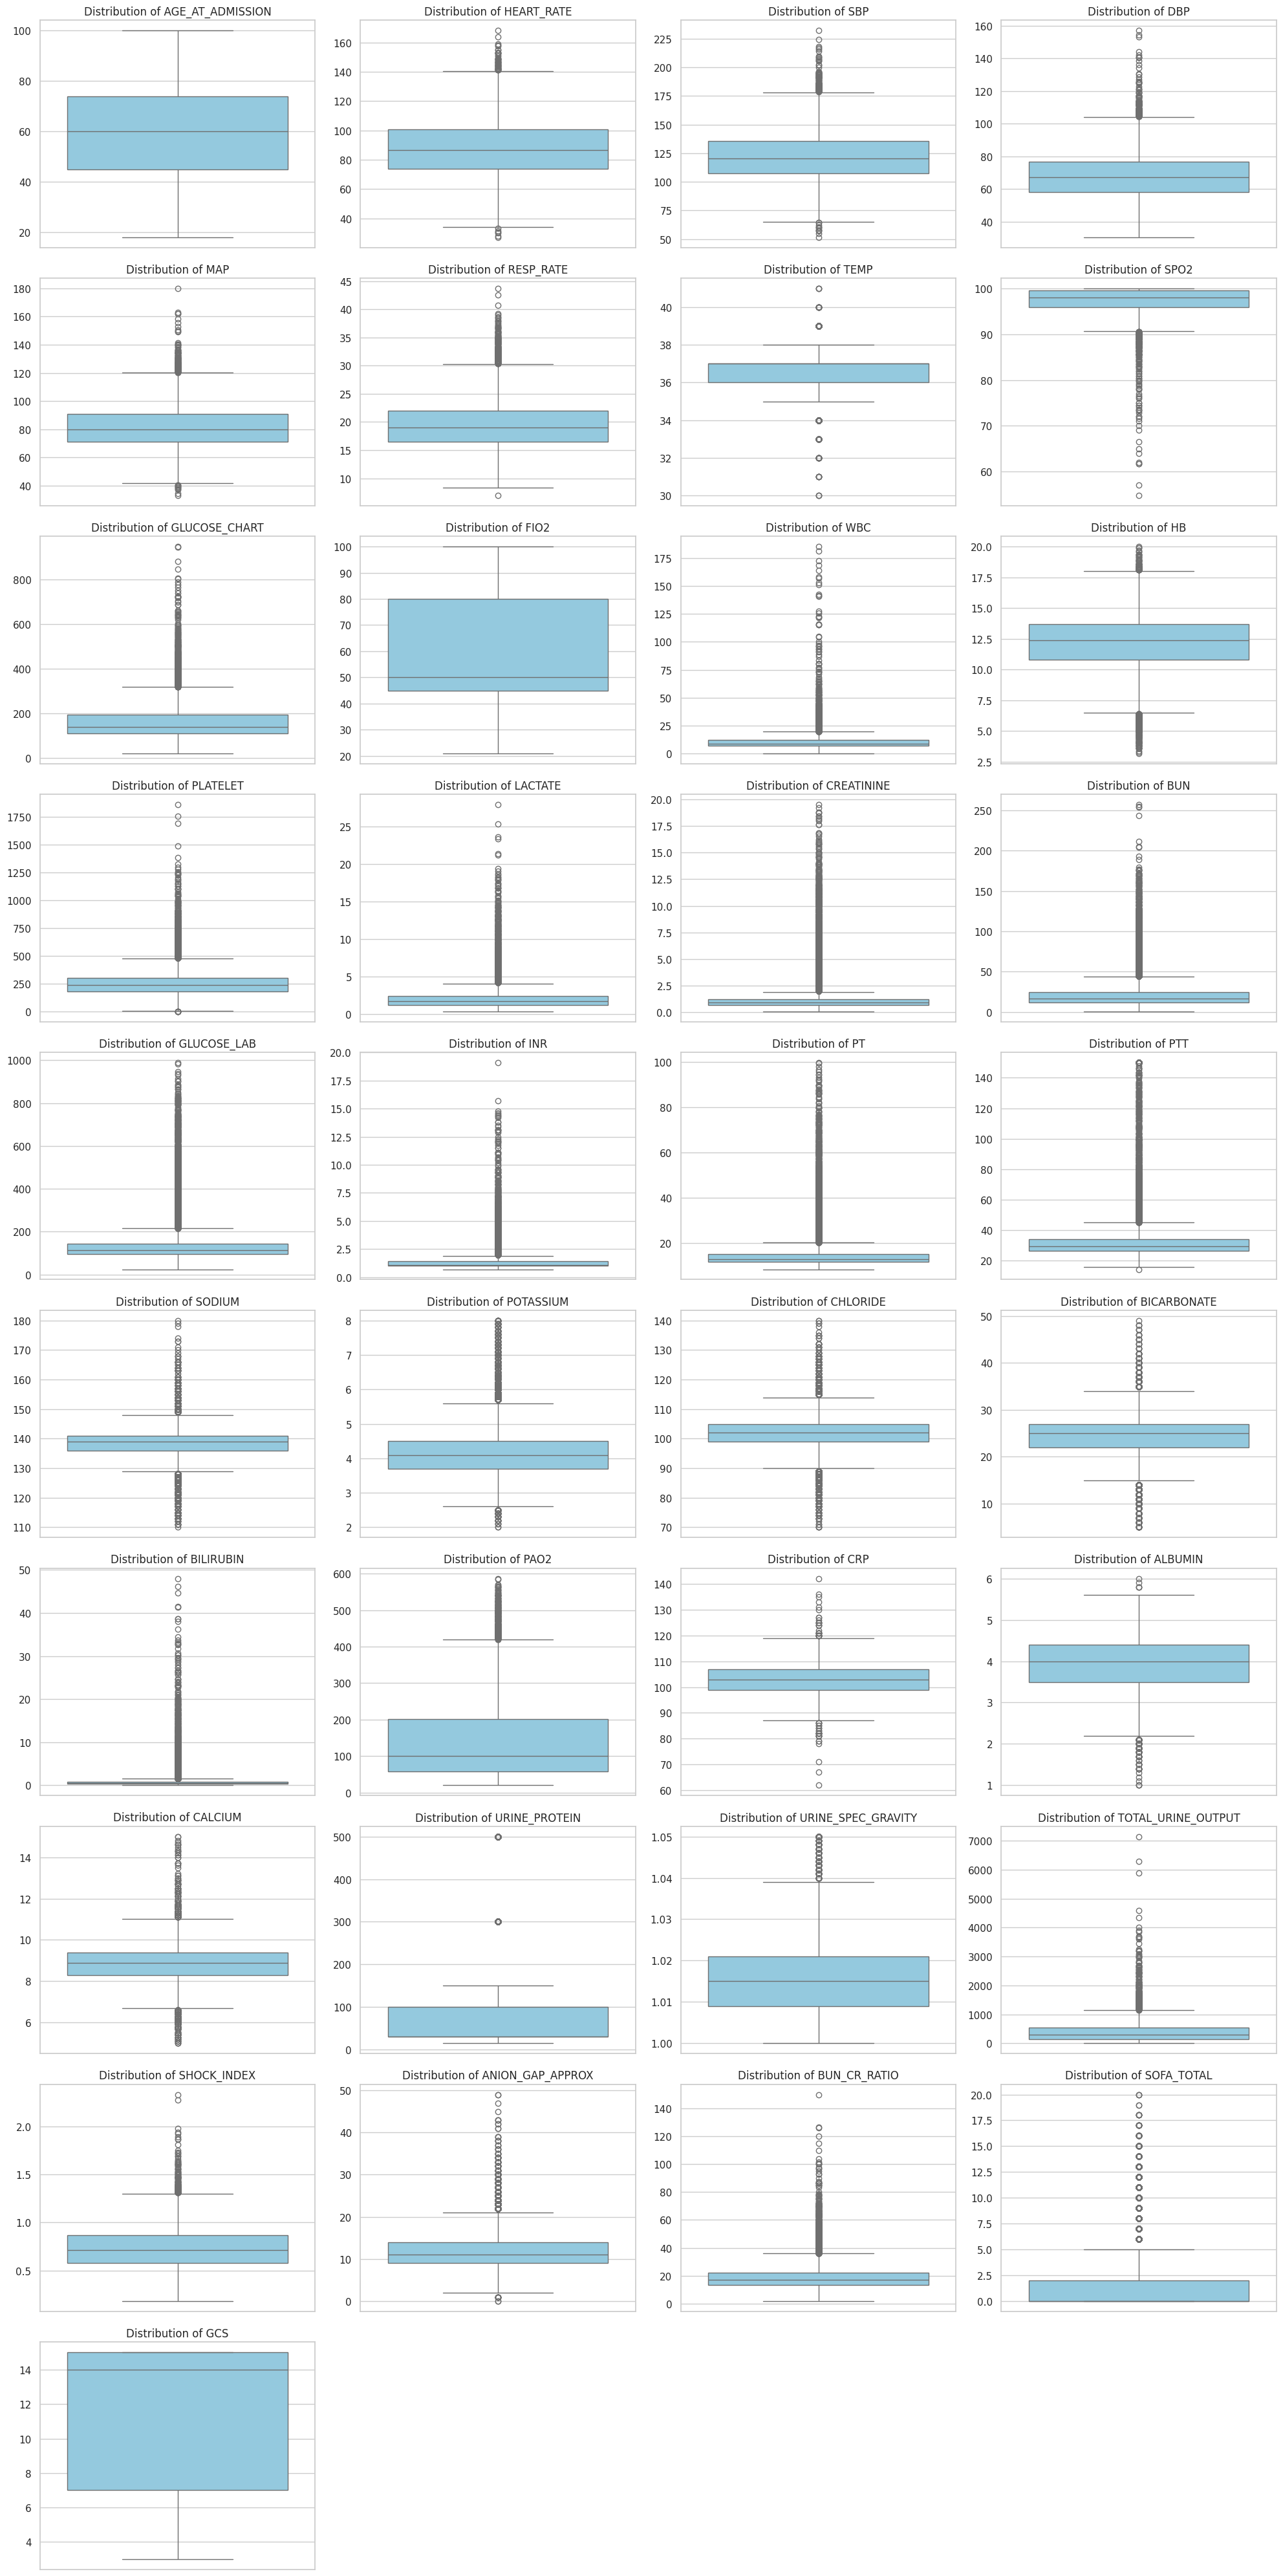

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기
# df = pd.read_csv('/content/drive/MyDrive/cohort_csv/data_after_outlier.csv')
df = pd.read_csv('data_after_outlier.csv')

# 2. 결측치 확인
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
}).sort_values(by='Percentage (%)', ascending=False)

print("===== 결측치 현황 요약 =====")
print(missing_data.head(20)) # 상위 20개 출력

# 3. 모든 수치형 변수에 대한 박스플롯 생성
# ID 관련 및 범주형 변수 제외
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
exclude_cols = ['SUBJECT_ID', 'HADM_ID', 'HOSPITAL_EXPIRE_FLAG', 'SEPSIS']
plot_cols = [c for c in numerical_cols if c not in exclude_cols]

# 시각화 설정
sns.set(style="whitegrid")
n_cols = 4
n_rows = (len(plot_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(20, 4 * n_rows))
for i, col in enumerate(plot_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.ylabel('')

plt.tight_layout()
plt.show()

# 4. 결측치 요약 CSV 저장 (필요시)
# missing_data.to_csv('missing_value_summary.csv', encoding='utf-8-sig')

In [ ]:
import pandas as pd

# 1. 데이터 불러오기
df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/cohort_csv/data_after_outlier.csv')

# 2. 결측치 처리를 하지 않을 식별자 및 타겟 컬럼 제외
exclude_cols = ['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'HOSPITAL_EXPIRE_FLAG', 'SEPSIS']
features = [col for col in df.columns if col not in exclude_cols]

# 3. 결측률 계산
missing_pct = (df[features].isnull().sum() / len(df)) * 100

# 4. 구간별 분류
cat1 = missing_pct[missing_pct >= 70].sort_values(ascending=False)
cat2 = missing_pct[(missing_pct >= 30) & (missing_pct < 70)].sort_values(ascending=False)
cat3 = missing_pct[missing_pct < 30].sort_values(ascending=False)

# 5. 결과 출력
print("="*50)
print(f"📊 [Category 1] 결측률 70% 이상 ({len(cat1)}개)")
print("👉 전략: 값 제거 + Missing Indicator만 생성")
print("-"*50)
for col, val in cat1.items():
    print(f"{col:<20} : {val:.2f}%")

print("\n" + "="*50)
print(f"📊 [Category 2] 결측률 30% ~ 70% ({len(cat2)}개)")
print("👉 전략: Missing Indicator + 단순 보정(Median)")
print("-"*50)
if len(cat2) == 0: print("해당하는 변수가 없습니다.")
for col, val in cat2.items():
    print(f"{col:<20} : {val:.2f}%")

print("\n" + "="*50)
print(f"📊 [Category 3] 결측률 30% 미만 ({len(cat3)}개)")
print("👉 전략: Missing Indicator + MICE 보정")
print("-"*50)
for col, val in cat3.items():
    print(f"{col:<20} : {val:.2f}%")

📊 [Category 1] 결측률 70% 이상 (15개)
👉 전략: 값 제거 + Missing Indicator만 생성
--------------------------------------------------
CRP                  : 95.81%
FIO2                 : 90.19%
PAO2                 : 88.80%
URINE_PROTEIN        : 88.51%
TOTAL_URINE_OUTPUT   : 85.02%
GLUCOSE_CHART        : 84.30%
GCS                  : 81.69%
TEMP                 : 81.31%
SPO2                 : 80.49%
DBP                  : 80.47%
SHOCK_INDEX          : 80.47%
SBP                  : 80.45%
MAP                  : 80.45%
HEART_RATE           : 80.37%
RESP_RATE            : 80.32%

📊 [Category 2] 결측률 30% ~ 70% (8개)
👉 전략: Missing Indicator + 단순 보정(Median)
--------------------------------------------------
ALBUMIN              : 69.70%
URINE_SPEC_GRAVITY   : 63.99%
CALCIUM              : 63.09%
LACTATE              : 61.11%
BILIRUBIN            : 60.54%
PTT                  : 50.90%
PT                   : 50.65%
INR                  : 50.57%

📊 [Category 3] 결측률 30% 미만 (15개)
👉 전략: Missing Indicator + MICE 보정

In [ ]:
df = pd.read_csv('/content/data_after_outlier.csv')


KeyError: 'SUBJECT_ID'